In [4]:
# ─────────────────────────────────────────────
# PURPOSE: Import required libraries and configure display settings
# ─────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import sqlalchemy as sa
from datetime import date

# Disable scientific notation for float display
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [5]:
# ─────────────────────────────────────────────
# PURPOSE: Load the analytical dataset from the intermediate data layer
# ─────────────────────────────────────────────
# Load the pre-processed analytical table from the pickle file
df = pd.read_pickle('../datos/intermedios/tablon_analitico.pickle')

In [6]:
df.head()

,usuario,sesion,evento,producto,precio,categoria,año,año_nuevo_ruso,black_friday,cyber_monday,...,festivo,hora,mes,navidad_occidental,navidad_ortodoxa,nombre_dia,pre_año_nuevo,san_valentin,semana_año,trimestre
fecha_hora,,,,,,,,,,,,,,,,,,,,,
2019-10-01 00:01:46+00:00,462033176,a18e0999-61a1-4218-8f8f-61ec1d375361,view,5843665,9.44,1487580005092295511,2019,0,0,0,...,0,0,10,0,0,Tuesday,0,0,40,4
2019-10-01 00:01:55+00:00,514753614,e2fecb2d-22d0-df2c-c661-15da44b3ccf1,cart,5868461,3.57,1487580013069861041,2019,0,0,0,...,0,0,10,0,0,Tuesday,0,0,40,4
2019-10-01 00:02:50+00:00,527418424,86e77869-afbc-4dff-9aa2-6b7dd8c90770,view,5877456,122.22,1487580006300255120,2019,0,0,0,...,0,0,10,0,0,Tuesday,0,0,40,4
2019-10-01 00:03:41+00:00,555448072,b5f72ceb-0730-44de-a932-d16db62390df,view,5649270,6.19,1487580013749338323,2019,0,0,0,...,0,0,10,0,0,Tuesday,0,0,40,4
2019-10-01 00:03:44+00:00,552006247,2d8f304b-de45-4e59-8f40-50c603843fe5,view,18082,16.03,1487580005411062629,2019,0,0,0,...,0,0,10,0,0,Tuesday,0,0,40,4


In [7]:
# ─────────────────────────────────────────────
# PURPOSE: Calculate conversion rates between funnel stages (view → cart → remove → purchase)
# ─────────────────────────────────────────────

# Count events per type; reindex ensures all four stages appear even if missing in the data
eventos = df['evento'].value_counts().reindex(
    ['view', 'cart', 'remove_from_cart', 'purchase'],
    fill_value=0
)

# Build a conversion rate Series using 'view' as the base (= 100%)
# Guard against division by zero with conditional expressions
analisis_eventos = pd.Series({
    'view': 100,
    'cart/view (%)': (eventos['cart'] / eventos['view'] * 100) if eventos['view'] != 0 else 0,                          # % of views that added to cart
    'remove_from_cart/cart (%)': (eventos['remove_from_cart'] / eventos['cart'] * 100) if eventos['cart'] != 0 else 0,  # % of carts that were removed
    'purchase/cart (%)': (eventos['purchase'] / eventos['cart'] * 100) if eventos['cart'] != 0 else 0                   # % of carts that converted to purchase
}).round(2)

analisis_eventos

view                        100.00
cart/view (%)                59.75
remove_from_cart/cart (%)    71.42
purchase/cart (%)            22.20
dtype: float64

In [8]:
# ─────────────────────────────────────────────
# PURPOSE: Build the conversion funnel DataFrame with cumulative percentages relative to views
# ─────────────────────────────────────────────

# All percentages are expressed relative to total views (base = 100%)
# 'remove_from_cart' and 'purchase' are chained through the cart stage to get cumulative rates
df_funnel = pd.DataFrame({
    'fase': ['Visualizaciones', 'Añadir a carrito', 'Sacar de carrito', 'Comprar'],
    'porcentaje': [
        100.00,                                                                                          # Base: 100% of views
        analisis_eventos['cart/view (%)'],                                                               # % of views that added to cart
        analisis_eventos['cart/view (%)'] * analisis_eventos['remove_from_cart/cart (%)'] / 100,        # Cumulative: cart rate × remove rate
        analisis_eventos['cart/view (%)'] * analisis_eventos['purchase/cart (%)'] / 100                 # Cumulative: cart rate × purchase rate
    ]
})

df_funnel

,fase,porcentaje
0,Visualizaciones,100.00
1,Añadir a carrito,59.75
2,Sacar de carrito,42.67
3,Comprar,13.26


In [9]:
# ─────────────────────────────────────────────
# PURPOSE: Visualize the conversion funnel using an interactive Plotly chart
# ─────────────────────────────────────────────
import plotly.graph_objects as go

# Create a funnel chart; textinfo shows both the raw value and % relative to the first stage
fig = go.Figure(go.Funnel(
    y = df_funnel['fase'],         # Funnel stage labels (vertical axis)
    x = df_funnel['porcentaje'],   # Cumulative percentage values (horizontal axis)
    textinfo = "value+percent initial"
))

fig.update_layout(
    title = "Embudo de Conversión",
    height = 500
)

fig.show()

In [10]:
# ─────────────────────────────────────────────
# PURPOSE: Pivot event counts per session to analyse user behaviour at session level
# ─────────────────────────────────────────────
# Group by session and event type, count products; unstack creates one column per event type
# Missing combinations (e.g. a session with no purchases) are filled with 0
sesiones = df.groupby(['sesion', 'evento']).producto.count().unstack(fill_value=0)
sesiones.head()

evento,cart,purchase,remove_from_cart,view
sesion,,,,
0000597b-de39-4a77-9fe5-02c8792ca14e,0,0,0,3
0000645a-8160-4a3d-91bf-154bff0a22e3,0,0,0,2
000090e1-da13-42b1-a31b-91a9ee5e6a88,0,0,0,1
0000b3cb-5422-4bf2-b8fe-5c1831d0dc1b,0,0,0,1
0000de26-bd58-42c9-9173-4763c76b398e,0,0,0,1


In [11]:
sesiones.mean().round(2)

evento
cart               1.29
purchase           0.29
remove_from_cart   0.92
view               2.16
dtype: float64

In [12]:
# ─────────────────────────────────────────────
# PURPOSE: Reorder session columns to follow the natural funnel sequence
# ─────────────────────────────────────────────
# Keep only the four funnel-stage columns in logical order (view → cart → remove → purchase)
sesiones = sesiones[['view', 'cart', 'remove_from_cart', 'purchase']]

In [13]:
sesiones.mean().round(2)


evento
view               2.16
cart               1.29
remove_from_cart   0.92
purchase           0.29
dtype: float64

**Insight 1:**

- Datos actuales de los principales eventos que nos sirven de baseline para futuras acciones de mejora:

view 2.16

cart 1.29

remove_from_cart 0.92

purchase 0.29 

In [14]:
# ─────────────────────────────────────────────
# PURPOSE: Aggregate event counts by hour of day to detect temporal activity patterns
# ─────────────────────────────────────────────
# Group by hour and event type; unstack pivots event types into separate columns
eventos_horas = df.groupby(['hora', 'evento']).producto.count().unstack(fill_value=0)
eventos_horas.head()

evento,cart,purchase,remove_from_cart,view
hora,,,,
0,6475,962,3238,8731
1,5555,1128,3930,7280
2,6433,1220,3509,8378
3,8544,1535,5331,11807
4,11242,2389,8095,18365


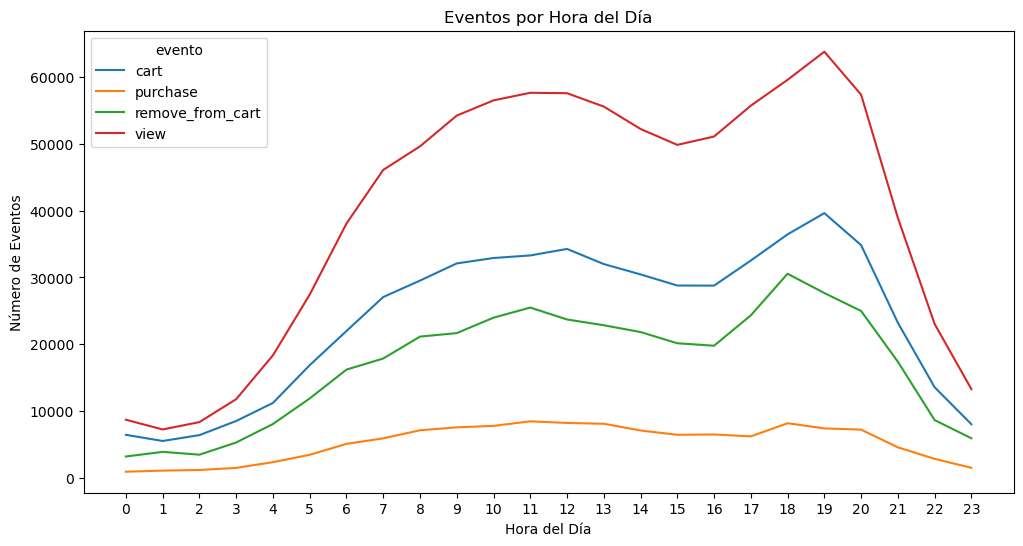

In [15]:
# ─────────────────────────────────────────────
# PURPOSE: Plot all event types by hour of day to identify activity peaks across the day
# ─────────────────────────────────────────────
eventos_horas.plot(kind='line', figsize=(12, 6))
plt.title('Eventos por Hora del Día')
plt.xlabel('Hora del Día')
plt.ylabel('Número de Eventos')
plt.xticks(range(24))   # Force all 24 hour ticks on the x-axis
plt.show()

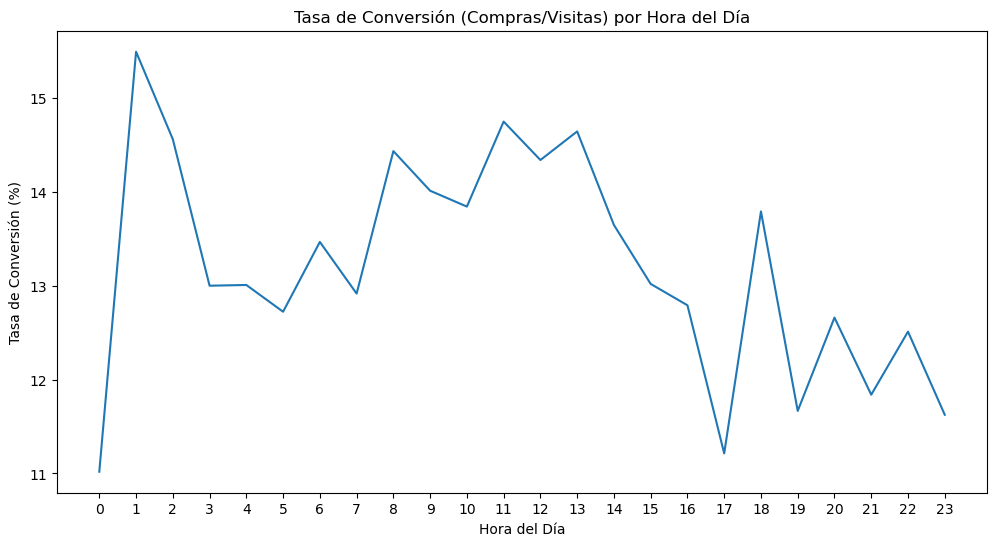

In [20]:
# ─────────────────────────────────────────────
# PURPOSE: Calculate and plot the hourly purchase-to-view conversion rate
# ─────────────────────────────────────────────

# Compute conversion rate: number of purchases divided by number of views per hour (as %)
eventos_horas['compras_visitas'] = eventos_horas['purchase'] / eventos_horas['view'] * 100

# Plot the hourly conversion rate to identify the best-converting hours of the day
eventos_horas['compras_visitas'].plot(kind='line', figsize=(12, 6))
plt.title('Tasa de Conversión (Compras/Visitas) por Hora del Día')
plt.xlabel('Hora del Día')
plt.ylabel('Tasa de Conversión (%)')
plt.xticks(range(24))   # Force all 24 hour ticks on the x-axis
plt.show()

**Insight 2:**

- Existen claras diferencias de comportamientos entre horas
- Las horas pico en que nuestros usuarios ven mas páginas y añaden más al carrito son entre las 09 y las 13, y entre las 18 y 20
- Las horas valle en que nuestros usuarios ven menos páginas y añaden menos al carrito son entre las 21 y las 08, y entre las 14 y las 16
- Sin embargo las horas donde más se compra son entre las 08 y las 13, y a las 18

Acciones operativas:

- Dividir las campañas publicitarias entre tráfico frío y retargeting
- Concentrar las de tráfico frío entre 09 y las 13, y entre las 18 y 20. Reduciendo el presupuesto fuera de ese horario.
- Concentrar las de retargeting entre las 08 y las 13, y a las 18. Reduciendo el presupuesto fuera de ese horario.

In [28]:
eventos_horas = eventos_horas[['view', 'cart', 'remove_from_cart', 'purchase', 'compras_visitas']]

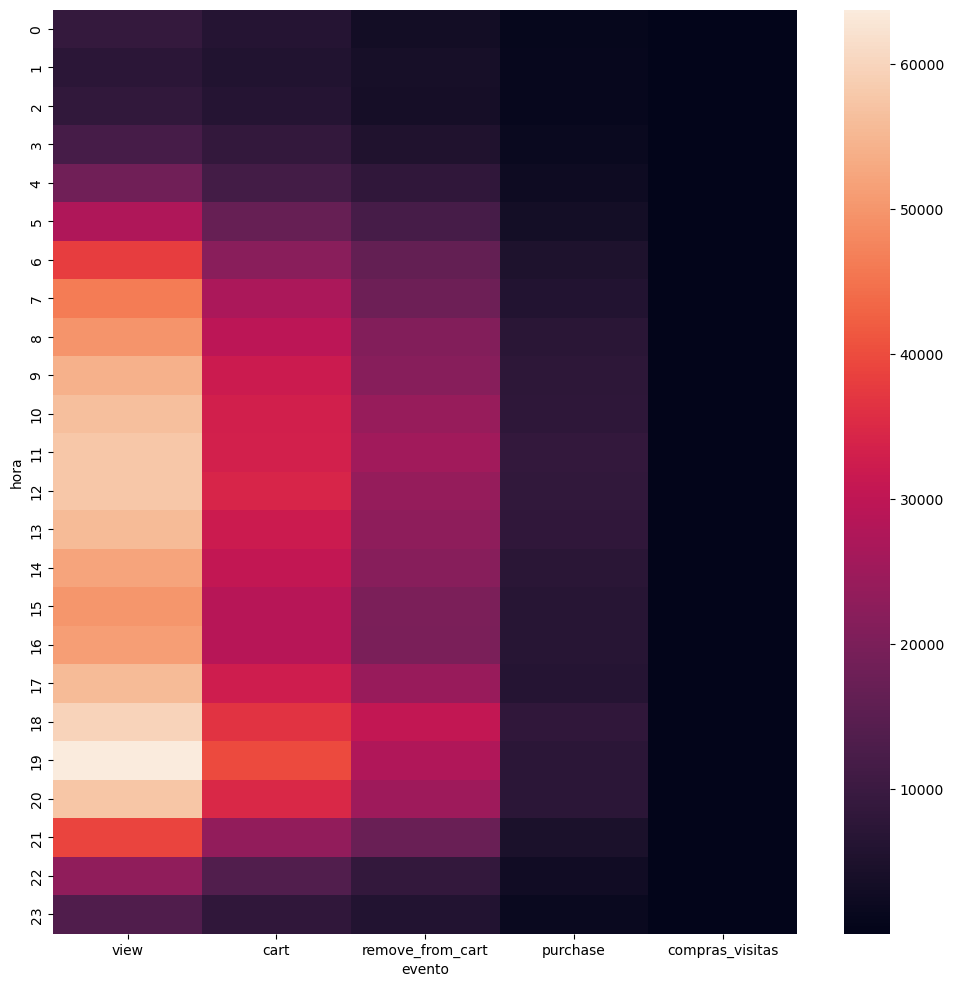

In [29]:
plt.figure(figsize=(12, 12))
sns.heatmap(eventos_horas);

In [30]:
def tipificar(variable):
    return (variable - variable.mean()) / variable.std()

In [31]:
eventos_horas_tip = eventos_horas.apply(tipificar)
eventos_horas_tip

evento,view,cart,remove_from_cart,purchase,compras_visitas
hora,,,,,
0,-1.60,-1.56,-1.63,-1.62,-1.83
1,-1.68,-1.64,-1.54,-1.56,1.91
2,-1.62,-1.56,-1.59,-1.53,1.13
3,-1.45,-1.37,-1.38,-1.41,-0.17
4,-1.11,-1.13,-1.06,-1.09,-0.17
5,-0.65,-0.63,-0.61,-0.68,-0.41
6,-0.10,-0.17,-0.10,-0.07,0.22
7,0.31,0.28,0.09,0.24,-0.24
8,0.49,0.50,0.48,0.69,1.03


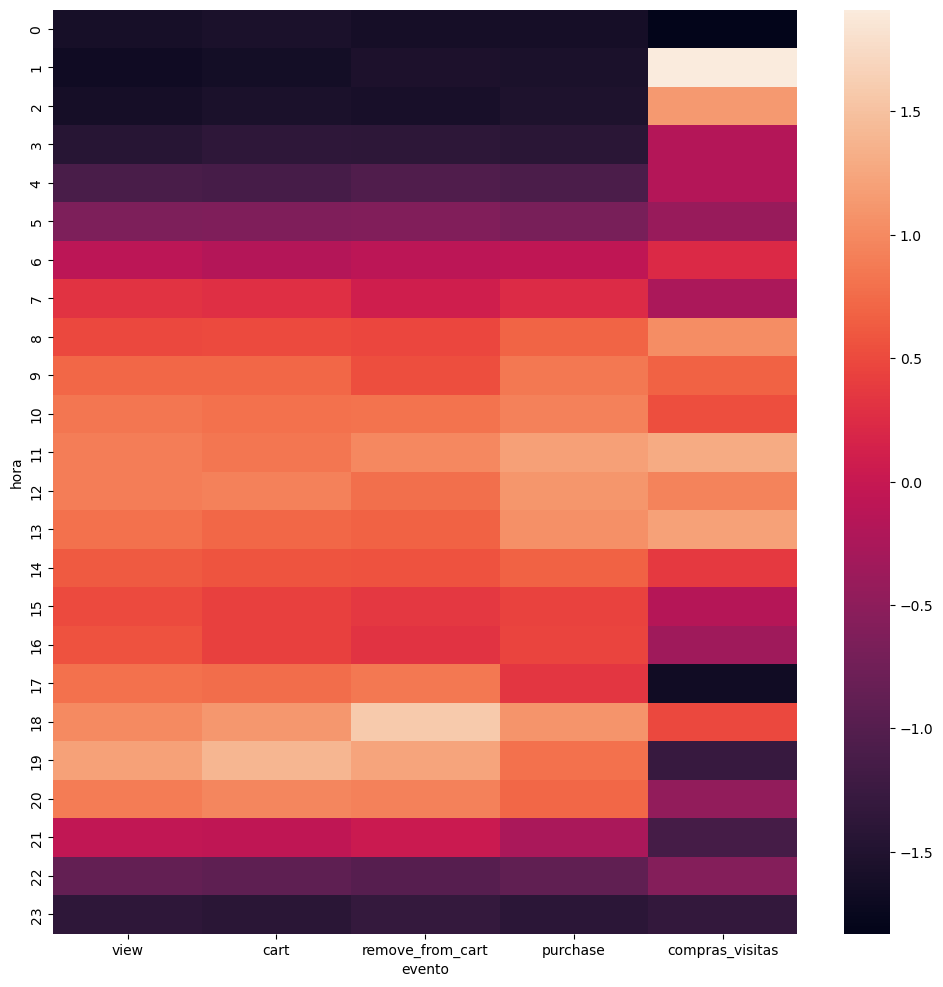

In [32]:
plt.figure(figsize=(12, 12))
sns.heatmap(eventos_horas_tip);

In [35]:
compras_por_mes = df[df['evento'] == 'purchase'].groupby('mes')['precio'].sum()
print(compras_por_mes)
print(compras_por_mes.mean())

mes
1    135174.45
2    121330.67
10   116519.04
11   146491.24
12   102034.20
Name: precio, dtype: float64
124309.92


In [58]:
eventos_semana = df.groupby('evento').resample('W')['evento'].count().unstack(level=0)
eventos_semana.index = eventos_semana.index.to_period('W').to_timestamp()
eventos_semana


C:\Users\phdel\AppData\Local\Temp\ipykernel_17468\1486923855.py:2: UserWarning:

Converting to PeriodArray/Index representation will drop timezone information.



evento,cart,purchase,remove_from_cart,view
fecha_hora,,,,
2019-09-30,31483,4440,14647,36353
2019-10-07,28151,5422,17989,44410
2019-10-14,23920,5033,15303,39486
2019-10-21,25651,5665,18411,40383
2019-10-28,24087,5746,16491,39365
2019-11-04,29142,6663,24008,46177
2019-11-11,25335,5141,17215,41170
2019-11-18,38069,9754,27973,56477
2019-11-25,31994,7493,23106,48883


In [57]:
eventos_semana = eventos_semana[['view', 'cart', 'remove_from_cart', 'purchase']]


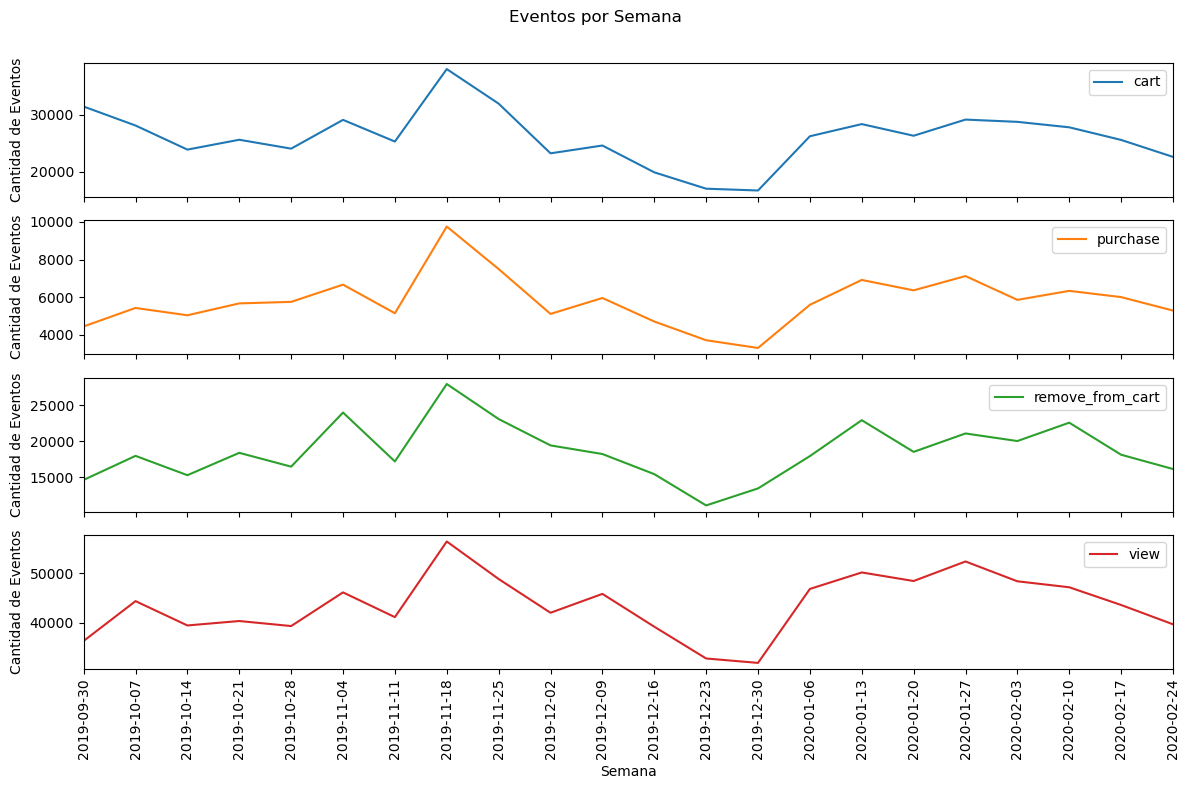

In [66]:
axes = eventos_semana.plot(subplots=True, kind='line', figsize=(12, 8), sharex=True)

plt.suptitle('Eventos por Semana')

for ax in np.ravel(axes):
    ax.set_xticks(eventos_semana.index)
    ax.set_xticklabels(eventos_semana.index.strftime('%Y-%m-%d'), rotation=90)
    ax.set_xlabel('Semana')
    ax.set_ylabel('Cantidad de Eventos')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [89]:
eventos_dia = (df['2019-11-01':'2019-12-31']
               .groupby('evento')
               .resample('D')['evento']
               .count()
               .unstack(level=0))
eventos_dia.index = eventos_dia.index.strftime('%Y-%m-%d')
eventos_dia

evento,cart,purchase,remove_from_cart,view
fecha_hora,,,,
2019-11-01,3565,709,2810,5352
2019-11-02,3015,912,2124,4857
2019-11-03,3540,755,2622,5583
2019-11-04,4652,676,4854,6248
2019-11-05,4118,753,2711,7213
...,...,...,...,...
2019-12-27,2023,507,1335,4058
2019-12-28,1744,329,1193,3704
2019-12-29,2134,263,1149,3939


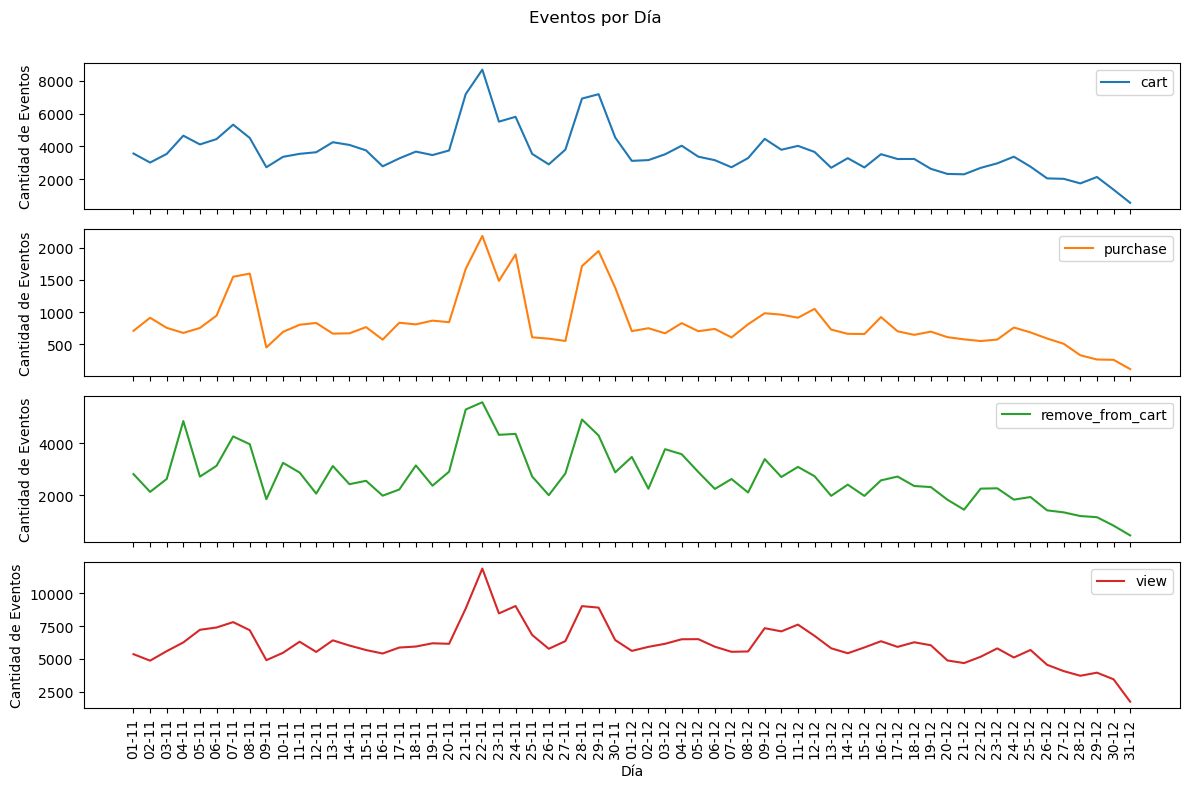

In [91]:
axes = eventos_dia.plot(subplots=True, kind='line', figsize=(12, 8), sharex=True)

plt.suptitle('Eventos por Día')

for ax in np.ravel(axes):
    ax.set_xticks(range(len(eventos_dia.index)))
    ax.set_xticklabels([d[8:10] + '-' + d[5:7] for d in eventos_dia.index], rotation=90)
    ax.set_xlabel('Día')
    ax.set_ylabel('Cantidad de Eventos')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

**Insight 3**:

- Diciembre tiene una tendencia claramente decreciente, lo que significa que lo clientes han adelantado sus compras
- En noviembre gran parte de las compras se producen en BlackFriday 
- Pero aún hay un pico mayor una semana antes, el día 22, posiblemente por el inicio de la semana de Black Friday

Acciones:

- Invertir la mayoría del presupuesto de marketing en Noviembre
- Con especial foco el inicio de la semana de BF y en el propío día de BF

In [109]:
df.columns



Index(['usuario', 'sesion', 'evento', 'producto', 'precio', 'categoria', 'año',
       'año_nuevo_ruso', 'black_friday', 'cyber_monday', 'defensor_patria',
       'dia', 'dia_semana', 'dia_soltero', 'es_fin_mes', 'es_fin_semana',
       'es_inicio_mes', 'fecha_sin_hora', 'festivo', 'hora', 'mes',
       'navidad_occidental', 'navidad_ortodoxa', 'nombre_dia', 'pre_año_nuevo',
       'san_valentin', 'semana_año', 'trimestre'],
      dtype='str')

In [129]:
clientes = df.loc[df['evento'] == 'purchase'].groupby('usuario').agg({'sesion': 'nunique',
                                                           'producto': 'count',
                                                           'precio': ['mean', 'sum'],
                                                           'fecha_sin_hora': 'max',
                                                           })
clientes.columns = ['compras', 'productos', 'precio_medio', 'gasto', 'fecha_ultima']
clientes = clientes.reset_index()

In [130]:
clientes

,usuario,compras,productos,precio_medio,gasto,fecha_ultima
0,25392526,1,3,7.38,22.14,2019-12-18
1,27756757,1,1,20.63,20.63,2020-01-27
2,50748978,1,9,1.11,10.01,2019-12-14
3,52747911,1,3,7.67,23.02,2019-10-10
4,65241811,1,5,8.36,41.79,2019-11-11
...,...,...,...,...,...,...
11035,621995551,1,5,2.09,10.46,2020-02-29
11036,622021687,1,1,13.33,13.33,2020-02-29
11037,622041514,1,3,0.63,1.90,2020-02-29
11038,622042698,1,3,28.04,84.13,2020-02-29


In [131]:
clientes['productos_por_compra'] = clientes['productos'] / clientes['compras']
clientes

,usuario,compras,productos,precio_medio,gasto,fecha_ultima,productos_por_compra
0,25392526,1,3,7.38,22.14,2019-12-18,3.00
1,27756757,1,1,20.63,20.63,2020-01-27,1.00
2,50748978,1,9,1.11,10.01,2019-12-14,9.00
3,52747911,1,3,7.67,23.02,2019-10-10,3.00
4,65241811,1,5,8.36,41.79,2019-11-11,5.00
...,...,...,...,...,...,...,...
11035,621995551,1,5,2.09,10.46,2020-02-29,5.00
11036,622021687,1,1,13.33,13.33,2020-02-29,1.00
11037,622041514,1,3,0.63,1.90,2020-02-29,3.00
11038,622042698,1,3,28.04,84.13,2020-02-29,3.00



# 💡 Insights de Negocio — Análisis de Clientes

---

## 🔴 Insight 4 — El negocio depende críticamente de una minoría de clientes

El **top 20% de clientes genera el 58.9% de los ingresos** (€366k sobre €622k totales), y el top 10% ya acumula el 42.4%. Estamos ante una **curva de Pareto muy pronunciada**: el negocio es estructuralmente frágil porque la mayor parte del revenue está concentrado en muy pocos usuarios.

**Acciones:**
- Implementar un programa de **fidelización VIP** (Champions + Leales RFM) con beneficios exclusivos para retener a ese 10-20% crítico.
- Crear alertas automáticas cuando un cliente del top 20% lleve más de 60 días sin comprar.
- Asignar un gestor de cuenta o campaña personalizada a los top 100 clientes por gasto.

---

## 🔴 Insight 5 — El 78.8% de los clientes solo ha comprado una vez

Casi **8 de cada 10 clientes son compradores únicos** (8.697 de 11.040). La tasa de recompra es muy baja. Esto revela un **problema grave de retención** y que el negocio está invirtiendo continuamente en captación sin capitalizar esa base.

**Acciones:**
- Diseñar una secuencia de **email post-compra** (3-7-15 días) con incentivo a la segunda compra (descuento, envío gratuito, recomendación personalizada).
- Crear una oferta de **"segunda compra"** específica para activar a los one-shot antes de que enfríen.
- Medir y fijar un objetivo de tasa de recompra como KPI principal de negocio.

---

## 🟡 Insight 6 — Los segmentos RFM revelan el estado real de la base de clientes

| Segmento | % Clientes | % Ingreso | Lectura |
|---|---|---|---|
| **Champions** | 16.3% | **42.8%** | Oro puro: compran frecuente, gastan mucho, son recientes |
| **Leales** | 26.3% | 26.2% | Buen perfil, susceptibles de convertirse en Champions |
| **Potenciales** | 34.0% | 22.9% | El grupo más numeroso; sin activar todavía |
| **En riesgo** | 17.1% | 6.8% | Llevan ~109 días sin comprar; se están yendo |
| **Perdidos** | 6.3% | 1.3% | Recencia media de 127 días; muy difícil recuperación |

**Acciones:**
- **Champions**: recompensar, solicitar reviews, upselling de productos premium.
- **Leales**: campaña de "siguiente nivel", bundles, suscripción o programa de puntos.
- **Potenciales**: nurturing con contenido de valor + oferta de activación.
- **En riesgo**: campaña de **reactivación urgente** con descuento o incentivo de tiempo limitado (ventana de 30 días antes de que pasen a Perdidos).
- **Perdidos**: secuencia de win-back de bajo coste (email únicamente); si no responden en 30 días, retirarlos de campañas activas.

---

## 🟡 Insight 7 — El gasto está muy sesgado: media €56 pero mediana €33

La **media de gasto (€56) casi duplica la mediana (€33)**, lo que confirma una distribución con **cola larga derecha** muy pronunciada (p99 = €394, máximo = €1.559). El cliente "típico" gasta bastante menos de lo que indican los promedios. Tomar decisiones basadas en la media lleva a errores de segmentación.

**Acciones:**
- Usar siempre la **mediana** como referencia para segmentar y establecer umbrales, no la media.
- Diseñar estrategias distintas para el segmento de **alto ticket** (p75-p99: €60-€394) y el segmento **masivo** (p25-p50: €16-€33).
- Para el segmento masivo: estrategias de **volumen y frecuencia** (más visitas, más ítems por cesta).
- Para el segmento alto ticket: estrategias de **valor unitario** (upsell, cross-sell, productos premium).

---

## 🟡 Insight 8 — El 36.3% de los clientes lleva entre 91 y 180 días sin comprar

Más de 4.000 clientes están en una **zona de alto riesgo de abandono definitivo**. Cruzando con el análisis RFM, este grupo coincide mayoritariamente con los segmentos "En riesgo" y "Potenciales". Son clientes que conocen la tienda pero han dejado de interactuar.

**Acciones:**
- Activar campaña de **reactivación segmentada** por tramo de recencia (91-120 días vs. 121-180 días, con mensajes distintos).
- El tramo 0-30 días (24.6%) es la base más sana: concentrar esfuerzos de upsell/cross-sell aquí mientras el cliente sigue activo.
- Establecer un **sistema de alertas de recencia** para detectar el momento exacto en que un cliente cruza los 60 días sin comprar (punto de inflexión antes de "En riesgo").

---

## 🟢 Insight 9 — El gasto está impulsado por el volumen de productos, no por el precio

La correlación más alta con `gasto` es la de `productos` (r=**0.836**), seguida de `compras` (r=0.611). La correlación de `precio_medio` con `gasto` es muy baja (r=0.115). Esto indica que **los clientes que más gastan no pagan productos más caros, sino que compran más unidades**.

**Acciones:**
- Optimizar estrategias de **cross-sell y "frequently bought together"** para incrementar el número de ítems por sesión.
- Diseñar **bundles o packs** que incentiven añadir más productos al carrito.
- Los descuentos de precio tienen **bajo impacto** en el gasto total; es más efectivo ofrecer "3x2" o "envío gratis a partir de X productos".

---

## 🟢 Insight 10 — El cuadrante "Alto gasto · Alta frecuencia" concentra el 84.7% del ingreso con el 50% de clientes

La segmentación cruzada por medianas es prácticamente **binaria**: los 5.522 clientes que superan la mediana tanto en gasto como en compras generan el 84.7% del revenue (€526k). Los otros 5.518 clientes, el 15.3% restante.

**Acciones:**
- Toda la inversión en retención debe concentrarse en el cuadrante **"Alto gasto · Alta frecuencia"**.
- El cuadrante **"Alto gasto · Baja frecuencia"** (clientes que gastan mucho pero compran poco) es el de mayor potencial de crecimiento: son compradores de alto valor que no han desarrollado hábito de compra recurrente. Una campaña de frecuencia dirigida a ellos puede tener ROI muy alto.

---

## 🔵 Insight 11 — Existen ~111 clientes con comportamiento anómalo que merecen revisión

111 clientes superan el **p99 de gasto (>€394)** y 107 superan el **p99 de productos/compra (>42 unidades/compra)**. Adicionalmente, 111 clientes tienen un precio medio inferior a €1.17, lo que puede indicar compras de artículos casi gratuitos o anomalías de registro.

**Acciones:**
- Revisar manualmente los top 20 en `productos_por_compra` para detectar posibles **revendedores** o bots (el cliente 556579890 compró 506 productos en 4 sesiones).
- Validar si los clientes de precio medio < €1.17 son compras legítimas o errores de datos / abuso de promociones.
- Separar estos outliers de los análisis de comportamiento general para no distorsionar métricas.


In [203]:

# ─────────────────────────────────────────────
# PURPOSE: Análisis completo de la tabla de clientes y exportación a Markdown
# ─────────────────────────────────────────────

fecha_referencia = clientes['fecha_ultima'].max()
lineas = []
lineas.append("# Análisis de Clientes\n")
lineas.append(f"_Generado el {date.today().strftime('%d/%m/%Y')} · Fecha de referencia: {fecha_referencia.strftime('%d/%m/%Y')}_\n")

# ── 1. Estadísticas descriptivas del gasto ──────────────────────────────────
lineas.append("## 1. Distribución del Gasto por Cliente\n")
desc_gasto = clientes['gasto'].describe(percentiles=[.25, .5, .75, .90, .95, .99])
lineas.append(desc_gasto.round(2).to_markdown())
lineas.append("")

# ── 2. Análisis de Pareto ────────────────────────────────────────────────────
lineas.append("\n## 2. Concentración del Ingreso (Pareto)\n")
total_gasto = clientes['gasto'].sum()
clientes_ord = clientes.sort_values('gasto', ascending=False).reset_index(drop=True)
for pct in [0.01, 0.05, 0.10, 0.20]:
    n = max(1, int(len(clientes_ord) * pct))
    gasto_top = clientes_ord.head(n)['gasto'].sum()
    lineas.append(f"- Top **{int(pct*100)}%** de clientes ({n:,}) → **{gasto_top/total_gasto*100:.1f}%** del ingreso total (€{gasto_top:,.2f})")
lineas.append("")

# ── 3. Compradores únicos vs recurrentes ─────────────────────────────────────
lineas.append("\n## 3. Compradores Únicos vs Recurrentes\n")
one_shot   = (clientes['compras'] == 1).sum()
recurrentes = (clientes['compras'] > 1).sum()
total_clientes = len(clientes)
lineas.append("| Segmento | Clientes | % del Total |")
lineas.append("|---|---|---|")
lineas.append(f"| One-shot (1 compra) | {one_shot:,} | {one_shot/total_clientes*100:.1f}% |")
lineas.append(f"| Recurrentes (>1 compra) | {recurrentes:,} | {recurrentes/total_clientes*100:.1f}% |")
lineas.append(f"| **Total** | **{total_clientes:,}** | **100%** |")
lineas.append("")

# ── 4. Distribución del número de compras ────────────────────────────────────
lineas.append("\n## 4. Distribución del Número de Compras por Cliente (top 10 valores)\n")
dist_compras_df = (clientes['compras']
                   .value_counts()
                   .sort_index()
                   .head(10)
                   .reset_index())
dist_compras_df.columns = ['Nº Compras', 'Clientes']
dist_compras_df['% del Total'] = (dist_compras_df['Clientes'] / total_clientes * 100).round(1)
lineas.append(dist_compras_df.to_markdown(index=False))
lineas.append("")

# ── 5. Top 20 clientes por gasto ─────────────────────────────────────────────
lineas.append("\n## 5. Top 20 Clientes por Gasto Total\n")
top20 = clientes_ord.head(20)[['usuario', 'compras', 'productos', 'precio_medio', 'gasto', 'fecha_ultima']].copy()
top20['gasto']       = top20['gasto'].round(2)
top20['precio_medio'] = top20['precio_medio'].round(2)
top20['% s/ total']  = (top20['gasto'] / total_gasto * 100).round(2)
lineas.append(top20.to_markdown(index=False))
lineas.append("")

# ── 6. Análisis RFM ───────────────────────────────────────────────────────────
lineas.append("\n## 6. Análisis RFM (Recencia · Frecuencia · Monetario)\n")

rfm = clientes.copy()
rfm['recencia'] = (pd.to_datetime(fecha_referencia) - pd.to_datetime(rfm['fecha_ultima'])).dt.days

rfm['R'] = pd.qcut(rfm['recencia'],              5, labels=[5,4,3,2,1]).astype(int)
rfm['F'] = pd.qcut(rfm['compras'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M'] = pd.qcut(rfm['gasto'].rank(method='first'),   5, labels=[1,2,3,4,5]).astype(int)
rfm['RFM_score'] = rfm['R'] + rfm['F'] + rfm['M']

def segmento_rfm(row):
    s = row['RFM_score']
    if s >= 13: return 'Champions'
    elif s >= 10: return 'Leales'
    elif s >= 7:  return 'Potenciales'
    elif s >= 5:  return 'En riesgo'
    else:         return 'Perdidos'

rfm['segmento'] = rfm.apply(segmento_rfm, axis=1)

rfm_resumen = rfm.groupby('segmento').agg(
    clientes        =('usuario',  'count'),
    gasto_medio     =('gasto',    'mean'),
    gasto_total     =('gasto',    'sum'),
    recencia_media  =('recencia', 'mean'),
    compras_medias  =('compras',  'mean')
).round(2).reset_index()
rfm_resumen['% clientes'] = (rfm_resumen['clientes'] / total_clientes * 100).round(1)
rfm_resumen['% ingreso']  = (rfm_resumen['gasto_total'] / total_gasto   * 100).round(1)
lineas.append(rfm_resumen.to_markdown(index=False))
lineas.append("")

# ── 7. Correlaciones clave ────────────────────────────────────────────────────
lineas.append("\n## 7. Correlaciones entre Variables de Cliente\n")
corr_matrix = clientes[['compras','productos','precio_medio','gasto','productos_por_compra']].corr().round(3)
lineas.append(corr_matrix.to_markdown())
lineas.append("")

# ── 8. Clientes dormidos por recencia ────────────────────────────────────────
lineas.append("\n## 8. Clientes Dormidos por Tramo de Recencia\n")
tramos   = [0, 30, 60, 90, 180, 9999]
etiquetas = ['0-30 días', '31-60 días', '61-90 días', '91-180 días', '>180 días']
rfm['tramo'] = pd.cut(rfm['recencia'], bins=tramos, labels=etiquetas)
rec_resumen = (rfm.groupby('tramo', observed=True)['usuario']
               .count()
               .reset_index()
               .rename(columns={'usuario':'Clientes', 'tramo':'Tramo recencia'}))
rec_resumen['%'] = (rec_resumen['Clientes'] / total_clientes * 100).round(1)
lineas.append(rec_resumen.to_markdown(index=False))
lineas.append("")

# ── 9. Segmentación cruzada gasto vs frecuencia ──────────────────────────────
lineas.append("\n## 9. Segmentación Cruzada: Gasto vs Frecuencia de Compra\n")
lineas.append(f"_(medianas usadas como corte: gasto={clientes['gasto'].median():.2f}€, compras={clientes['compras'].median():.0f})_\n")

def cuadrante(row):
    g = row['gasto'] >= clientes['gasto'].median()
    c = row['compras'] >= clientes['compras'].median()
    if   g and     c: return 'Alto gasto · Alta frecuencia'
    elif g and not c: return 'Alto gasto · Baja frecuencia'
    elif not g and c: return 'Bajo gasto · Alta frecuencia'
    else:             return 'Bajo gasto · Baja frecuencia'

clientes['cuadrante'] = clientes.apply(cuadrante, axis=1)
cuad_resumen = clientes.groupby('cuadrante').agg(
    clientes    =('usuario', 'count'),
    gasto_medio =('gasto',   'mean'),
    gasto_total =('gasto',   'sum')
).round(2).reset_index()
cuad_resumen['% clientes'] = (cuad_resumen['clientes'] / total_clientes * 100).round(1)
cuad_resumen['% ingreso']  = (cuad_resumen['gasto_total'] / total_gasto   * 100).round(1)
lineas.append(cuad_resumen.to_markdown(index=False))
lineas.append("")

# ── 10. Detección de outliers ─────────────────────────────────────────────────
lineas.append("\n## 10. Detección de Outliers\n")
q99_gasto  = clientes['gasto'].quantile(0.99)
q99_ppc    = clientes['productos_por_compra'].quantile(0.99)
q01_precio = clientes['precio_medio'].quantile(0.01)
lineas.append("| Tipo de Outlier | Umbral | Nº Clientes |")
lineas.append("|---|---|---|")
lineas.append(f"| Gasto extremadamente alto (>p99) | €{q99_gasto:.2f} | {(clientes['gasto'] > q99_gasto).sum()} |")
lineas.append(f"| Productos/compra extremadamente alto (>p99) | {q99_ppc:.1f} uds | {(clientes['productos_por_compra'] > q99_ppc).sum()} |")
lineas.append(f"| Precio medio extremadamente bajo (<p1) | €{q01_precio:.2f} | {(clientes['precio_medio'] < q01_precio).sum()} |")
lineas.append("")

# ── Guardar fichero ───────────────────────────────────────────────────────────
output_path = Path('../docs/analisis.md')
output_path.write_text('\n'.join(lineas), encoding='utf-8')
print(f"✅ Archivo guardado en: {output_path.resolve()}")


✅ Archivo guardado en: C:\Users\phdel\Desktop\DS4B\CASO 3 BA\ECommerce\docs\analisis.md


In [204]:
c = df.loc[df.evento == 'purchase', ['usuario', 'mes']]
c

,usuario,mes
fecha_hora,,
2019-10-01 00:26:49+00:00,536128518,10
2019-10-01 00:26:49+00:00,536128518,10
2019-10-01 00:26:49+00:00,536128518,10
2019-10-01 00:26:49+00:00,536128518,10
2019-10-01 00:26:49+00:00,536128518,10
...,...,...
2020-02-29 22:29:19+00:00,622065819,2
2020-02-29 22:29:19+00:00,622065819,2
2020-02-29 22:29:19+00:00,622065819,2


In [205]:
c = pd.crosstab(c.usuario.values, c.mes.values, rownames=['usuario'], colnames=['mes'], dropna=False)
c

mes,1,2,10,11,12
usuario,,,,,
25392526,0,0,0,0,3
27756757,1,0,0,0,0
50748978,0,0,0,0,9
52747911,0,0,3,0,0
65241811,0,0,0,5,0
...,...,...,...,...,...
621995551,0,5,0,0,0
622021687,0,1,0,0,0
622041514,0,3,0,0,0


In [206]:
meses = {1: 'Enero', 2: 'Febrero', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'}

c.columns = [meses[m] for m in c.columns]

In [207]:
c = c[['Octubre', 'Noviembre', 'Diciembre', 'Enero', 'Febrero']]
c

,Octubre,Noviembre,Diciembre,Enero,Febrero
usuario,,,,,
25392526,0,0,3,0,0
27756757,0,0,0,1,0
50748978,0,0,9,0,0
52747911,3,0,0,0,0
65241811,0,5,0,0,0
...,...,...,...,...,...
621995551,0,0,0,0,5
622021687,0,0,0,0,1
622041514,0,0,0,0,3


In [208]:
c1 = c.loc[(c['Octubre'] == 0) & (c['Noviembre'] > 0)]
c1

,Octubre,Noviembre,Diciembre,Enero,Febrero
usuario,,,,,
65241811,0,5,0,0,0
80577370,0,10,0,0,0
93279832,0,27,17,0,0
94390236,0,3,0,0,0
101281763,0,4,0,0,0
...,...,...,...,...,...
579798049,0,5,0,0,0
579813390,0,2,0,0,5
579834429,0,1,0,0,0


In [209]:
def binarizar(variable):
    if variable > 0:
        return 1
    else:
        return 0

In [210]:
c1_b = c1.map(binarizar)
c1_b

,Octubre,Noviembre,Diciembre,Enero,Febrero
usuario,,,,,
65241811,0,1,0,0,0
80577370,0,1,0,0,0
93279832,0,1,1,0,0
94390236,0,1,0,0,0
101281763,0,1,0,0,0
...,...,...,...,...,...
579798049,0,1,0,0,0
579813390,0,1,0,0,1
579834429,0,1,0,0,0


In [211]:
c1_f = c1_b.sum() / c1_b.shape[0] * 100
c1_f

Octubre       0.00
Noviembre   100.00
Diciembre     9.58
Enero         9.96
Febrero       7.69
dtype: float64

In [212]:
c2 = c.loc[(c['Noviembre'] == 0) & (c['Diciembre'] > 0)]
c2_b = c2.map(binarizar)
c2_f = c2_b.sum() / c2_b.shape[0] * 100
c2_f['Octubre'] = 0
c2_f

Octubre       0.00
Noviembre     0.00
Diciembre   100.00
Enero        10.43
Febrero       7.77
dtype: float64

In [213]:
c3 = c.loc[(c['Diciembre'] == 0) & (c['Enero'] > 0)]
c3_b = c3.map(binarizar)
c3_f = c3_b.sum() / c3_b.shape[0] * 100
c3_f[['Octubre', 'Noviembre']] = 0
c3_f

Octubre       0.00
Noviembre     0.00
Diciembre     0.00
Enero       100.00
Febrero      11.76
dtype: float64

In [214]:
cohortes = pd.DataFrame([c1_f, c2_f, c3_f])
cohortes.drop(columns=['Octubre'], inplace=True)
cohortes

,Noviembre,Diciembre,Enero,Febrero
0,100.00,9.58,9.96,7.69
1,0.00,100.00,10.43,7.77
2,0.00,0.00,100.00,11.76


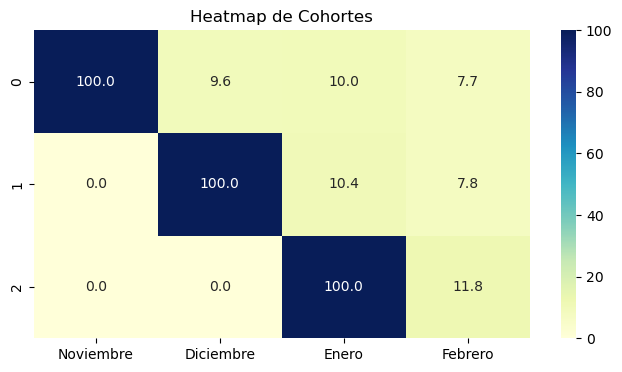

In [215]:
# Heatmap de cohortes
plt.figure(figsize=(8, 4))
sns.heatmap(cohortes, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Heatmap de Cohortes")
plt.show()

## Insight 12  

El 90% de los clientes ya no estan activos en el 2 mes. 

**Acciones:**
- Crear un plan de fidelización y desarrollo despues de su primera compra 

# LIFE TIME VALUE

In [216]:
clientes

,usuario,compras,productos,precio_medio,gasto,fecha_ultima,productos_por_compra,cuadrante
0,25392526,1,3,7.38,22.14,2019-12-18,3.00,Bajo gasto · Alta frecuencia
1,27756757,1,1,20.63,20.63,2020-01-27,1.00,Bajo gasto · Alta frecuencia
2,50748978,1,9,1.11,10.01,2019-12-14,9.00,Bajo gasto · Alta frecuencia
3,52747911,1,3,7.67,23.02,2019-10-10,3.00,Bajo gasto · Alta frecuencia
4,65241811,1,5,8.36,41.79,2019-11-11,5.00,Alto gasto · Alta frecuencia
...,...,...,...,...,...,...,...,...
11035,621995551,1,5,2.09,10.46,2020-02-29,5.00,Bajo gasto · Alta frecuencia
11036,622021687,1,1,13.33,13.33,2020-02-29,1.00,Bajo gasto · Alta frecuencia
11037,622041514,1,3,0.63,1.90,2020-02-29,3.00,Bajo gasto · Alta frecuencia
11038,622042698,1,3,28.04,84.13,2020-02-29,3.00,Alto gasto · Alta frecuencia


In [217]:
c1

,Octubre,Noviembre,Diciembre,Enero,Febrero
usuario,,,,,
65241811,0,5,0,0,0
80577370,0,10,0,0,0
93279832,0,27,17,0,0
94390236,0,3,0,0,0
101281763,0,4,0,0,0
...,...,...,...,...,...
579798049,0,5,0,0,0
579813390,0,2,0,0,5
579834429,0,1,0,0,0


In [218]:
# Extraer los usuarios de c1 en una lista llamada maestro_c1
maestro_c1 = c1.index.tolist()

In [223]:
# Seleccionar de clientes solo los que aparezcan en maestros_c1 y cuya fecha_ullima sea inferior a '2020-02-01'
ltv_c1 = clientes[clientes['usuario'].isin(maestro_c1) & (pd.to_datetime(clientes['fecha_ultima']) < '2020-02-01')]
ltv_c1

,usuario,compras,productos,precio_medio,gasto,fecha_ultima,productos_por_compra,cuadrante
4,65241811,1,5,8.36,41.79,2019-11-11,5.00,Alto gasto · Alta frecuencia
6,80577370,2,10,10.62,106.24,2019-11-29,5.00,Alto gasto · Alta frecuencia
8,93279832,2,44,3.19,140.51,2019-12-19,22.00,Alto gasto · Alta frecuencia
9,94390236,1,3,9.73,29.20,2019-11-07,3.00,Bajo gasto · Alta frecuencia
13,101281763,1,4,9.98,39.90,2019-11-30,4.00,Alto gasto · Alta frecuencia
...,...,...,...,...,...,...,...,...
7699,579752153,1,4,6.79,27.14,2019-11-30,4.00,Bajo gasto · Alta frecuencia
7702,579798049,1,5,2.10,10.52,2019-11-30,5.00,Bajo gasto · Alta frecuencia
7705,579834429,1,1,27.14,27.14,2019-11-30,1.00,Bajo gasto · Alta frecuencia
7708,579900887,2,11,5.67,62.34,2019-12-02,5.50,Alto gasto · Alta frecuencia


In [226]:
ltv_c1['gasto'].describe()

count   2437.00
mean      49.66
std       60.57
min        0.13
25%       16.85
50%       32.78
75%       57.88
max     1241.53
Name: gasto, dtype: float64

In [229]:
maestro_c2 = c2.index.tolist()
ltv_c2 = clientes[clientes['usuario'].isin(maestro_c2)]
ltv_c2

,usuario,compras,productos,precio_medio,gasto,fecha_ultima,productos_por_compra,cuadrante
0,25392526,1,3,7.38,22.14,2019-12-18,3.00,Bajo gasto · Alta frecuencia
2,50748978,1,9,1.11,10.01,2019-12-14,9.00,Bajo gasto · Alta frecuencia
10,97980555,2,14,6.54,91.60,2020-01-27,7.00,Alto gasto · Alta frecuencia
11,98079173,2,14,2.25,31.43,2019-12-20,7.00,Bajo gasto · Alta frecuencia
12,99666343,1,1,4.00,4.00,2019-12-17,1.00,Bajo gasto · Alta frecuencia
...,...,...,...,...,...,...,...,...
8874,594889340,1,2,5.00,10.00,2019-12-30,2.00,Bajo gasto · Alta frecuencia
8876,594932513,1,1,24.29,24.29,2019-12-30,1.00,Bajo gasto · Alta frecuencia
8877,594965776,1,2,4.91,9.82,2019-12-31,2.00,Bajo gasto · Alta frecuencia
8878,594993496,1,6,7.17,43.02,2019-12-30,6.00,Alto gasto · Alta frecuencia


In [231]:
ltv_c2['gasto'].describe()

count   2099.00
mean      51.46
std       65.92
min        0.48
25%       15.71
50%       30.15
75%       57.83
max      745.10
Name: gasto, dtype: float64

## Insight 13  

El LFT3M mediano de nuestros clientes es de 31€


## RFM

In [233]:
clientes.info()

<class 'pandas.DataFrame'>
RangeIndex: 11040 entries, 0 to 11039
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   usuario               11040 non-null  int64  
 1   compras               11040 non-null  int64  
 2   productos             11040 non-null  int64  
 3   precio_medio          11040 non-null  float64
 4   gasto                 11040 non-null  float64
 5   fecha_ultima          11040 non-null  object 
 6   productos_por_compra  11040 non-null  float64
 7   cuadrante             11040 non-null  str    
dtypes: float64(3), int64(3), object(1), str(1)
memory usage: 690.1+ KB


In [232]:
clientes

,usuario,compras,productos,precio_medio,gasto,fecha_ultima,productos_por_compra,cuadrante
0,25392526,1,3,7.38,22.14,2019-12-18,3.00,Bajo gasto · Alta frecuencia
1,27756757,1,1,20.63,20.63,2020-01-27,1.00,Bajo gasto · Alta frecuencia
2,50748978,1,9,1.11,10.01,2019-12-14,9.00,Bajo gasto · Alta frecuencia
3,52747911,1,3,7.67,23.02,2019-10-10,3.00,Bajo gasto · Alta frecuencia
4,65241811,1,5,8.36,41.79,2019-11-11,5.00,Alto gasto · Alta frecuencia
...,...,...,...,...,...,...,...,...
11035,621995551,1,5,2.09,10.46,2020-02-29,5.00,Bajo gasto · Alta frecuencia
11036,622021687,1,1,13.33,13.33,2020-02-29,1.00,Bajo gasto · Alta frecuencia
11037,622041514,1,3,0.63,1.90,2020-02-29,3.00,Bajo gasto · Alta frecuencia
11038,622042698,1,3,28.04,84.13,2020-02-29,3.00,Alto gasto · Alta frecuencia


In [235]:
# Convertir fecha_ultima a datetime
clientes['fecha_ultima'] = pd.to_datetime(clientes['fecha_ultima'])

# Obtener la fecha máxima
fecha_maxima = clientes['fecha_ultima'].max()

# Calcular diferencia en días
clientes['dias_diferencia'] = (fecha_maxima - clientes['fecha_ultima']).dt.days

# Crear M (Monetary): 1 = menos gasto, 5 = más gasto
clientes['M'] = pd.qcut(clientes['gasto'], q=5, labels=False, duplicates='drop') + 1

# Crear F (Frequency): 1 = menos compras, 5 = más compras
clientes['F'] = pd.qcut(clientes['compras'], q=5, labels=False, duplicates='drop') + 1

# Crear R (Recency): 5 = más reciente (menos días), 1 = menos reciente (más días)
clientes['R'] = 5 - pd.qcut(clientes['dias_diferencia'], q=5, labels=False, duplicates='drop')

# Convertir a enteros
clientes['M'] = clientes['M'].astype(int)
clientes['F'] = clientes['F'].astype(int)
clientes['R'] = clientes['R'].astype(int)

# Crear RFM concatenando R, F y M
clientes['RFM'] = clientes['R'].astype(str) + clientes['F'].astype(str) + clientes['M'].astype(str)

clientes[['usuario', 'gasto', 'compras', 'fecha_ultima', 'dias_diferencia', 'R', 'F', 'M', 'RFM']].head(10)

,usuario,gasto,compras,fecha_ultima,dias_diferencia,R,F,M,RFM
0,25392526,22.14,1,2019-12-18,73,3,1,2,312
1,27756757,20.63,1,2020-01-27,33,4,1,2,412
2,50748978,10.01,1,2019-12-14,77,3,1,1,311
3,52747911,23.02,1,2019-10-10,142,1,1,2,112
4,65241811,41.79,1,2019-11-11,110,2,1,4,214
5,74332980,31.88,1,2019-10-23,129,1,1,3,113
6,80577370,106.24,2,2019-11-29,92,2,1,5,215
7,88211255,106.87,4,2020-02-25,4,5,2,5,525
8,93279832,140.51,2,2019-12-19,72,3,1,5,315
9,94390236,29.20,1,2019-11-07,114,1,1,3,113


In [237]:
clientes

,usuario,compras,productos,precio_medio,gasto,fecha_ultima,productos_por_compra,cuadrante,dias_diferencia,M,F,R,RFM
0,25392526,1,3,7.38,22.14,2019-12-18,3.00,Bajo gasto · Alta frecuencia,73,2,1,3,312
1,27756757,1,1,20.63,20.63,2020-01-27,1.00,Bajo gasto · Alta frecuencia,33,2,1,4,412
2,50748978,1,9,1.11,10.01,2019-12-14,9.00,Bajo gasto · Alta frecuencia,77,1,1,3,311
3,52747911,1,3,7.67,23.02,2019-10-10,3.00,Bajo gasto · Alta frecuencia,142,2,1,1,112
4,65241811,1,5,8.36,41.79,2019-11-11,5.00,Alto gasto · Alta frecuencia,110,4,1,2,214
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11035,621995551,1,5,2.09,10.46,2020-02-29,5.00,Bajo gasto · Alta frecuencia,0,1,1,5,511
11036,622021687,1,1,13.33,13.33,2020-02-29,1.00,Bajo gasto · Alta frecuencia,0,1,1,5,511
11037,622041514,1,3,0.63,1.90,2020-02-29,3.00,Bajo gasto · Alta frecuencia,0,1,1,5,511
11038,622042698,1,3,28.04,84.13,2020-02-29,3.00,Alto gasto · Alta frecuencia,0,5,1,5,515


In [236]:
# Verificar la distribución de cada componente RFM
print("Distribución de R (Recency):")
print(clientes['R'].value_counts().sort_index())
print("\nDistribución de F (Frequency):")
print(clientes['F'].value_counts().sort_index())
print("\nDistribución de M (Monetary):")
print(clientes['M'].value_counts().sort_index())
print(f"\nTotal de combinaciones RFM únicas: {clientes['RFM'].nunique()}")

Distribución de R (Recency):
R
1    2165
2    2202
3    2235
4    2160
5    2278
Name: count, dtype: int64

Distribución de F (Frequency):
F
1    10117
2      923
Name: count, dtype: int64

Distribución de M (Monetary):
M
1    2219
2    2199
3    2206
4    2209
5    2207
Name: count, dtype: int64

Total de combinaciones RFM únicas: 45


In [239]:
# Media de gasto por variable M 
clientes.groupby('M')['gasto'].mean()


M
1     9.94
2    19.04
3    32.98
4    53.70
5   165.94
Name: gasto, dtype: float64

In [240]:
# Maximo de fecha_ultima por variable R
clientes.groupby('R')['fecha_ultima'].max()

R
1   2019-11-07
2   2019-12-06
3   2020-01-11
4   2020-02-04
5   2020-02-29
Name: fecha_ultima, dtype: datetime64[s]

In [241]:
# Media de compras por variable F
clientes.groupby('F')['compras'].mean()

F
1   1.14
2   4.24
Name: compras, dtype: float64

In [244]:
# Crea una nueva variable llamada valor_RFM que sea la suma R, F y M
clientes['valor_RFM'] = clientes['R'] + clientes['F'] + clientes['M']
clientes

,usuario,compras,productos,precio_medio,gasto,fecha_ultima,productos_por_compra,cuadrante,dias_diferencia,M,F,R,RFM,valor_RFM
0,25392526,1,3,7.38,22.14,2019-12-18,3.00,Bajo gasto · Alta frecuencia,73,2,1,3,312,6
1,27756757,1,1,20.63,20.63,2020-01-27,1.00,Bajo gasto · Alta frecuencia,33,2,1,4,412,7
2,50748978,1,9,1.11,10.01,2019-12-14,9.00,Bajo gasto · Alta frecuencia,77,1,1,3,311,5
3,52747911,1,3,7.67,23.02,2019-10-10,3.00,Bajo gasto · Alta frecuencia,142,2,1,1,112,4
4,65241811,1,5,8.36,41.79,2019-11-11,5.00,Alto gasto · Alta frecuencia,110,4,1,2,214,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11035,621995551,1,5,2.09,10.46,2020-02-29,5.00,Bajo gasto · Alta frecuencia,0,1,1,5,511,7
11036,622021687,1,1,13.33,13.33,2020-02-29,1.00,Bajo gasto · Alta frecuencia,0,1,1,5,511,7
11037,622041514,1,3,0.63,1.90,2020-02-29,3.00,Bajo gasto · Alta frecuencia,0,1,1,5,511,7
11038,622042698,1,3,28.04,84.13,2020-02-29,3.00,Alto gasto · Alta frecuencia,0,5,1,5,515,11


In [248]:
clientes.info()

<class 'pandas.DataFrame'>
RangeIndex: 11040 entries, 0 to 11039
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype        
---  ------                --------------  -----        
 0   usuario               11040 non-null  int64        
 1   compras               11040 non-null  int64        
 2   productos             11040 non-null  int64        
 3   precio_medio          11040 non-null  float64      
 4   gasto                 11040 non-null  float64      
 5   fecha_ultima          11040 non-null  datetime64[s]
 6   productos_por_compra  11040 non-null  float64      
 7   cuadrante             11040 non-null  str          
 8   dias_diferencia       11040 non-null  int64        
 9   M                     11040 non-null  int64        
 10  F                     11040 non-null  int64        
 11  R                     11040 non-null  int64        
 12  RFM                   11040 non-null  str          
 13  valor_RFM             11040 non-null  int6

# ANÁLISIS RFM PROFUNDO — Dimensiones, Segmentación y Acciones CRO

> **Objetivo**: Explotar las variables R, F, M, RFM y valor_RFM ya construidas para obtener insights de negocio accionables sobre los clientes del ecommerce de cosméticos.

## Plan de análisis
1. Segmentación formal de clientes (5 segmentos)
2. Análisis independiente de cada dimensión R, F, M
3. Heatmaps cruzados R×F y R×M (intensidad de gasto)
4. Curva de valor por valor_RFM
5. Distribución y perfil de segmentos
6. Identificación de clientes en riesgo de fuga y potenciales convertibles
7. Top combinaciones RFM code
8. Generación del informe ejecutivo

In [252]:
# ─────────────────────────────────────────────────────────────────────────────
# PASO 1 · Segmentación formal de clientes en 5 grupos RFM
# Usamos valor_RFM (R+F+M, rango 3-15) ya calculado en clientes
# ─────────────────────────────────────────────────────────────────────────────

def clasif_rfm(v):
    if v >= 12: return 'Champions'
    elif v >= 9: return 'Leales'
    elif v >= 7: return 'Potenciales'
    elif v >= 5: return 'En riesgo'
    else:        return 'Perdidos'

clientes['segmento_rfm'] = clientes['valor_RFM'].apply(clasif_rfm)

orden_seg   = ['Champions', 'Leales', 'Potenciales', 'En riesgo', 'Perdidos']
colores_seg = {'Champions': '#27ae60', 'Leales': '#2980b9',
               'Potenciales': '#f39c12', 'En riesgo': '#e67e22', 'Perdidos': '#c0392b'}

total_cl = len(clientes)
total_gs = clientes['gasto'].sum()

resumen_seg = (
    clientes.groupby('segmento_rfm')
    .agg(
        clientes         = ('usuario',              'count'),
        gasto_medio      = ('gasto',                'mean'),
        gasto_total      = ('gasto',                'sum'),
        recencia_media   = ('dias_diferencia',      'mean'),
        compras_medias   = ('compras',              'mean'),
        ppc_medio        = ('productos_por_compra', 'mean'),
    )
    .round(2)
    .reindex([s for s in orden_seg if s in clientes['segmento_rfm'].unique()])
)
resumen_seg['pct_clientes'] = (resumen_seg['clientes'] / total_cl * 100).round(1)
resumen_seg['pct_ingreso']  = (resumen_seg['gasto_total'] / total_gs   * 100).round(1)

print("=== RESUMEN POR SEGMENTO RFM ===")
print(resumen_seg.to_string())


=== RESUMEN POR SEGMENTO RFM ===
              clientes  gasto_medio  gasto_total  recencia_media  compras_medias  ppc_medio  pct_clientes  pct_ingreso
segmento_rfm                                                                                                          
Champions          366       253.13     92644.70           10.72            5.16      11.76          3.30        14.90
Leales            2560       100.96    258453.78           31.47            1.79      11.92         23.20        41.60
Potenciales       3479        49.05    170632.03           60.12            1.19       8.24         31.50        27.50
En riesgo         3206        25.28     81035.73           91.19            1.06       5.46         29.00        13.00
Perdidos          1429        13.14     18783.36          121.72            1.02       3.51         12.90         3.00


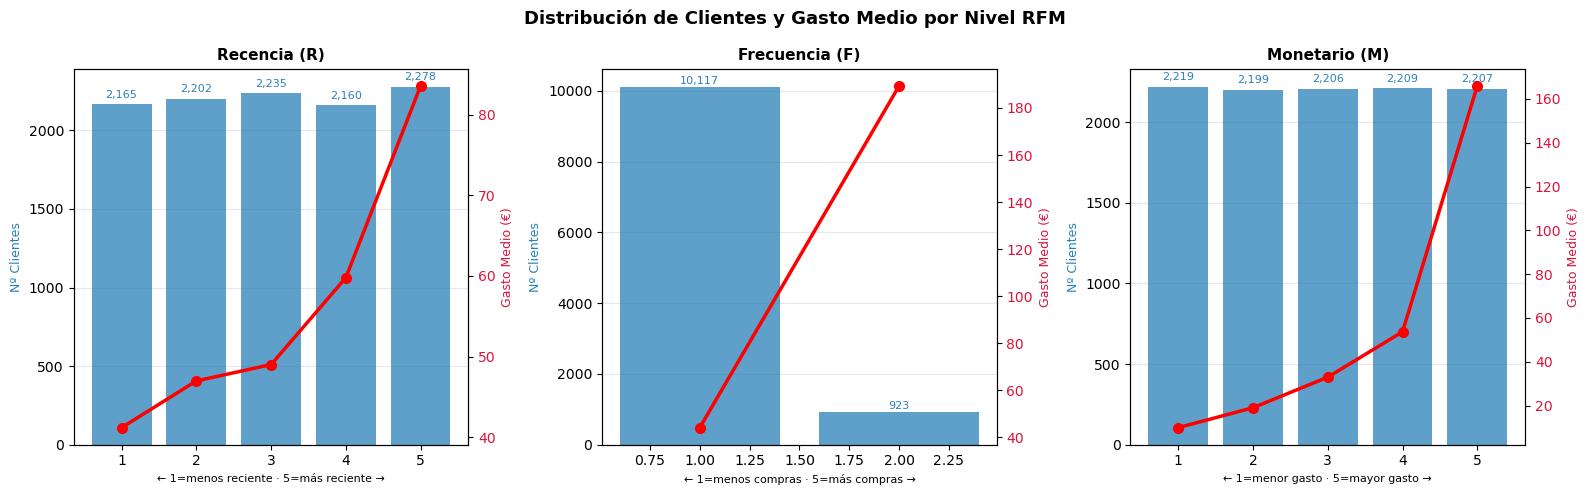

In [253]:
# ─────────────────────────────────────────────────────────────────────────────
# PASO 2 · Análisis independiente de cada dimensión R, F, M
# Para cada nivel (1-5) mostramos nº clientes y gasto medio
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribución de Clientes y Gasto Medio por Nivel RFM', fontsize=13, fontweight='bold')

dimensiones = [
    ('R', 'Recencia', '← 1=menos reciente · 5=más reciente →'),
    ('F', 'Frecuencia', '← 1=menos compras · 5=más compras →'),
    ('M', 'Monetario',  '← 1=menor gasto · 5=mayor gasto →'),
]

for ax, (dim, nombre, nota) in zip(axes, dimensiones):
    d = (clientes.groupby(dim)
         .agg(clientes=('usuario', 'count'), gasto_medio=('gasto', 'mean'))
         .reset_index())
    bars = ax.bar(d[dim], d['clientes'], color='#2980b9', alpha=0.75, zorder=2)
    ax.set_xlabel(nota, fontsize=8)
    ax.set_ylabel('Nº Clientes', color='#2980b9', fontsize=9)
    ax.set_title(f'{nombre} ({dim})', fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, zorder=1)
    for bar, val in zip(bars, d['clientes']):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 30, f'{val:,}',
                ha='center', va='bottom', fontsize=8, color='#2980b9')
    ax2 = ax.twinx()
    ax2.plot(d[dim], d['gasto_medio'], 'r-o', linewidth=2.5,
             markersize=7, label='Gasto medio (€)', zorder=3)
    ax2.set_ylabel('Gasto Medio (€)', color='crimson', fontsize=9)
    ax2.tick_params(axis='y', labelcolor='crimson')

plt.tight_layout()
os.makedirs('../entregables/graficos', exist_ok=True)
plt.savefig('../entregables/graficos/rfm_dimensiones.png', dpi=150, bbox_inches='tight')
plt.show()


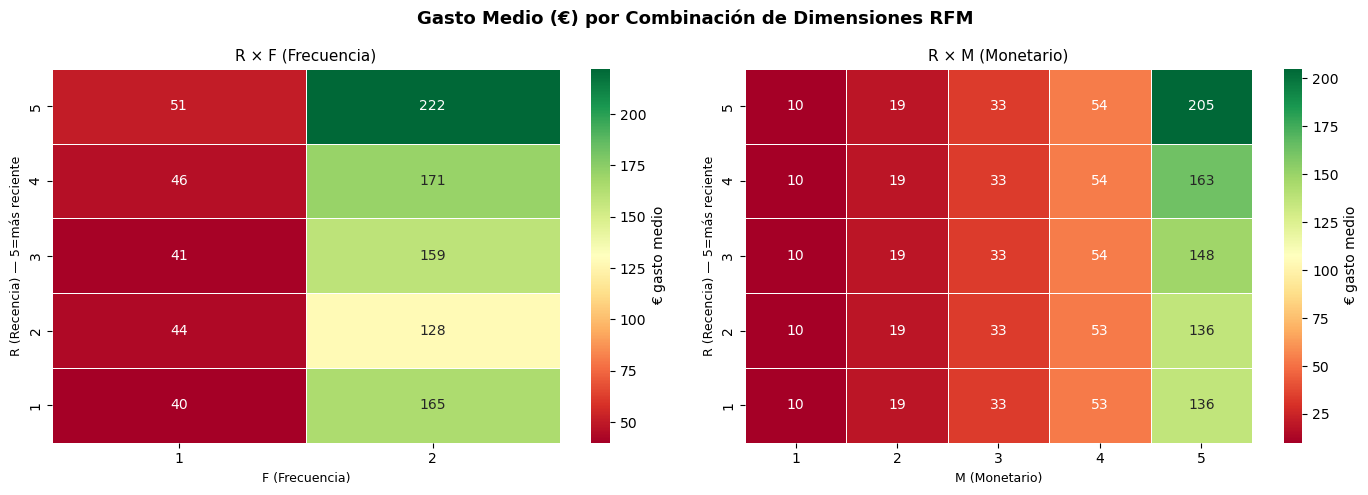

In [254]:
# ─────────────────────────────────────────────────────────────────────────────
# PASO 3 · Heatmaps cruzados R×F y R×M
# Muestra qué combinaciones de dimensiones generan mayor gasto medio
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Gasto Medio (€) por Combinación de Dimensiones RFM', fontsize=13, fontweight='bold')

for ax, (col, titulo) in zip(axes, [('F', 'F (Frecuencia)'), ('M', 'M (Monetario)')]):
    pivot = (clientes
             .pivot_table(values='gasto', index='R', columns=col, aggfunc='mean')
             .round(0)
             .sort_index(ascending=False))
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn', ax=ax,
                linewidths=0.5, cbar_kws={'label': '€ gasto medio'}, annot_kws={'size': 10})
    ax.set_title(f'R × {titulo}', fontsize=11)
    ax.set_xlabel(titulo, fontsize=9)
    ax.set_ylabel('R (Recencia) — 5=más reciente', fontsize=9)

plt.tight_layout()
plt.savefig('../entregables/graficos/rfm_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()


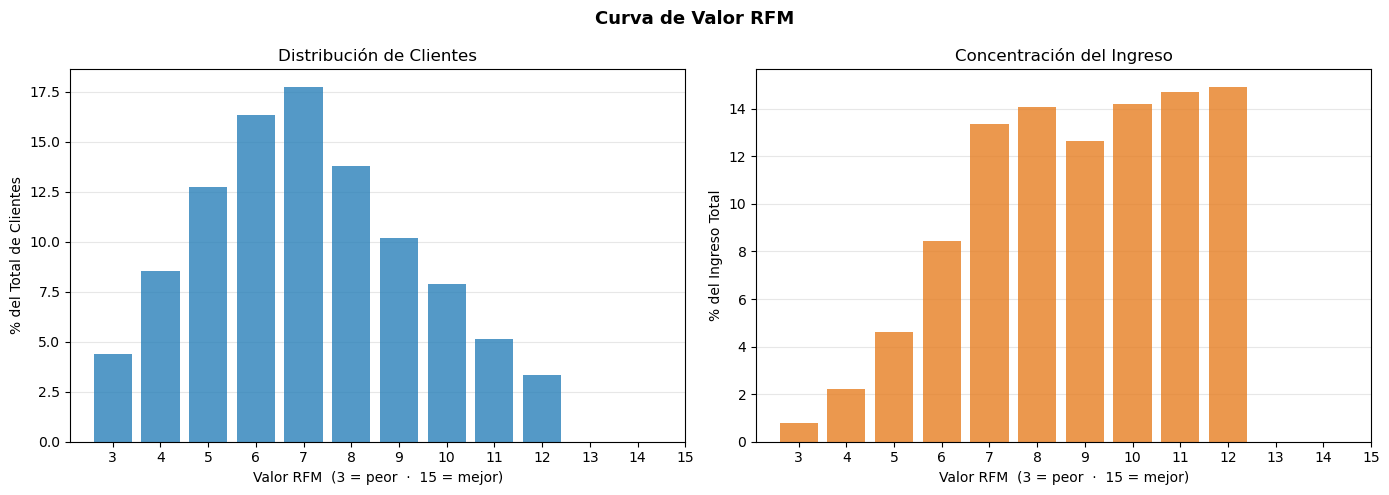


Tabla resumen por valor_RFM:
 valor_RFM  clientes  gasto_medio  gasto_total  pct_ingreso  pct_clientes
         3       486        10.11      4911.40         0.79          4.40
         4       943        14.71     13871.96         2.23          8.54
         5      1404        20.45     28706.57         4.62         12.72
         6      1802        29.04     52329.16         8.42         16.32
         7      1957        42.45     83079.31        13.37         17.73
         8      1522        57.52     87552.72        14.09         13.79
         9      1122        70.15     78711.99        12.66         10.16
        10       872       101.30     88331.16        14.21          7.90
        11       566       161.50     91410.63        14.71          5.13
        12       366       253.13     92644.70        14.91          3.32


In [256]:
# ─────────────────────────────────────────────────────────────────────────────
# PASO 4 · Curva de valor_RFM  (valor_RFM de 3 a 15)
# Muestra cómo se concentran clientes e ingresos en cada nivel de valor
# ─────────────────────────────────────────────────────────────────────────────

vr = (clientes.groupby('valor_RFM')
      .agg(clientes=('usuario', 'count'),
           gasto_medio=('gasto', 'mean'),
           gasto_total=('gasto', 'sum'))
      .reset_index())
vr['pct_ingreso']  = (vr['gasto_total'] / total_gs * 100).round(2)
vr['pct_clientes'] = (vr['clientes']    / total_cl * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Curva de Valor RFM', fontsize=13, fontweight='bold')

axes[0].bar(vr['valor_RFM'], vr['pct_clientes'], color='#2980b9', alpha=0.8, zorder=2)
axes[0].set_xlabel('Valor RFM  (3 = peor  ·  15 = mejor)')
axes[0].set_ylabel('% del Total de Clientes')
axes[0].set_title('Distribución de Clientes')
axes[0].set_xticks(range(3, 16))
axes[0].grid(axis='y', alpha=0.3, zorder=1)

axes[1].bar(vr['valor_RFM'], vr['pct_ingreso'], color='#e67e22', alpha=0.8, zorder=2)
axes[1].set_xlabel('Valor RFM  (3 = peor  ·  15 = mejor)')
axes[1].set_ylabel('% del Ingreso Total')
axes[1].set_title('Concentración del Ingreso')
axes[1].set_xticks(range(3, 16))
axes[1].grid(axis='y', alpha=0.3, zorder=1)

plt.tight_layout()
plt.savefig('../entregables/graficos/rfm_curva_valor.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTabla resumen por valor_RFM:")
print(vr.to_string(index=False))


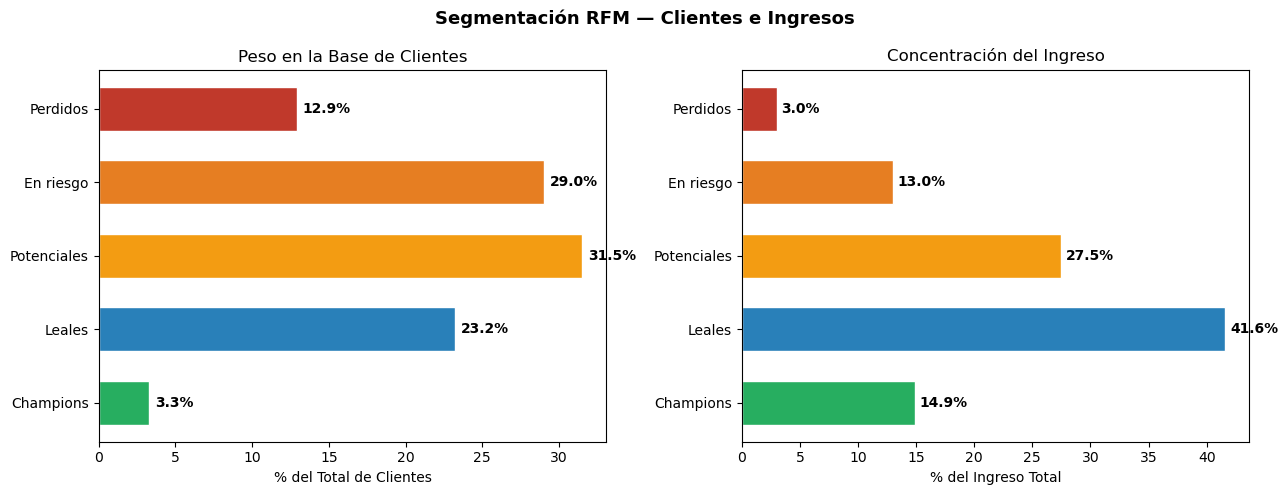

In [257]:
# ─────────────────────────────────────────────────────────────────────────────
# PASO 5 · Distribución visual de los 5 segmentos RFM
# ─────────────────────────────────────────────────────────────────────────────

seg_plot     = [s for s in orden_seg if s in resumen_seg.index]
colores_plot = [colores_seg[s] for s in seg_plot]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Segmentación RFM — Clientes e Ingresos', fontsize=13, fontweight='bold')

# Clientes
bars0 = axes[0].barh(seg_plot, resumen_seg.loc[seg_plot, 'pct_clientes'],
                     color=colores_plot, edgecolor='white', height=0.6)
axes[0].set_xlabel('% del Total de Clientes')
axes[0].set_title('Peso en la Base de Clientes')
for bar, val in zip(bars0, resumen_seg.loc[seg_plot, 'pct_clientes']):
    axes[0].text(val + 0.4, bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}%', va='center', fontweight='bold')

# Ingresos
bars1 = axes[1].barh(seg_plot, resumen_seg.loc[seg_plot, 'pct_ingreso'],
                     color=colores_plot, edgecolor='white', height=0.6)
axes[1].set_xlabel('% del Ingreso Total')
axes[1].set_title('Concentración del Ingreso')
for bar, val in zip(bars1, resumen_seg.loc[seg_plot, 'pct_ingreso']):
    axes[1].text(val + 0.4, bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../entregables/graficos/rfm_segmentos.png', dpi=150, bbox_inches='tight')
plt.show()


In [258]:
# ─────────────────────────────────────────────────────────────────────────────
# PASO 6 · Perfiles de segmentos clave + identificación de oportunidades
# ─────────────────────────────────────────────────────────────────────────────

# Subgrupos de interés
champions          = clientes[clientes['segmento_rfm'] == 'Champions']
leales             = clientes[clientes['segmento_rfm'] == 'Leales']
en_riesgo          = clientes[clientes['segmento_rfm'] == 'En riesgo']
perdidos           = clientes[clientes['segmento_rfm'] == 'Perdidos']
potenciales        = clientes[clientes['segmento_rfm'] == 'Potenciales']

# Clientes con buen historial (M>=3 y F>=2) pero recencia baja (R<=2)  → riesgo de fuga real
fuga_alto_valor    = clientes[(clientes['M'] >= 3) & (clientes['F'] >= 2) & (clientes['R'] <= 2)]

# Clientes recientes (R>=4), 1 sola compra, gasto medio-alto (M>=3) → potencial de segunda compra
potencial_2da      = clientes[(clientes['R'] >= 4) & (clientes['F'] == 1) & (clientes['M'] >= 3)]

# One-shot recientes (R>=4, F=1, M cualquiera) → primer objetivo retención
oneshot_reciente   = clientes[(clientes['R'] >= 4) & (clientes['F'] == 1)]

print("=" * 60)
print("PERFILES DE SEGMENTOS CLAVE")
print("=" * 60)

for nombre, grupo in [
    ('Champions',               champions),
    ('Leales',                  leales),
    ('Potenciales',             potenciales),
    ('En riesgo',               en_riesgo),
    ('Perdidos',                perdidos),
    ('Riesgo de fuga (alto valor)', fuga_alto_valor),
    ('Potencial 2ª compra (R>=4, F=1, M>=3)', potencial_2da),
    ('One-shot recientes (R>=4, F=1)', oneshot_reciente),
]:
    print(f"\n--- {nombre} ---")
    print(f"  Clientes:          {len(grupo):>6,}  ({len(grupo)/total_cl*100:.1f}%)")
    print(f"  Gasto total:   €{grupo['gasto'].sum():>10,.2f}  ({grupo['gasto'].sum()/total_gs*100:.1f}% del total)")
    print(f"  Gasto medio:   €{grupo['gasto'].mean():>8,.2f}")
    print(f"  Compras medias:    {grupo['compras'].mean():>6.1f}")
    print(f"  Recencia media:    {grupo['dias_diferencia'].mean():>6.0f} días")
    print(f"  Prod/compra media: {grupo['productos_por_compra'].mean():>6.1f}")


PERFILES DE SEGMENTOS CLAVE

--- Champions ---
  Clientes:             366  (3.3%)
  Gasto total:   € 92,644.70  (14.9% del total)
  Gasto medio:   €  253.13
  Compras medias:       5.2
  Recencia media:        11 días
  Prod/compra media:   11.8

--- Leales ---
  Clientes:           2,560  (23.2%)
  Gasto total:   €258,453.78  (41.6% del total)
  Gasto medio:   €  100.96
  Compras medias:       1.8
  Recencia media:        31 días
  Prod/compra media:   11.9

--- Potenciales ---
  Clientes:           3,479  (31.5%)
  Gasto total:   €170,632.03  (27.5% del total)
  Gasto medio:   €   49.05
  Compras medias:       1.2
  Recencia media:        60 días
  Prod/compra media:    8.2

--- En riesgo ---
  Clientes:           3,206  (29.0%)
  Gasto total:   € 81,035.73  (13.0% del total)
  Gasto medio:   €   25.28
  Compras medias:       1.1
  Recencia media:        91 días
  Prod/compra media:    5.5

--- Perdidos ---
  Clientes:           1,429  (12.9%)
  Gasto total:   € 18,783.36  (3.0% del

Top 20 combinaciones RFM por volumen de clientes:
RFM  clientes  gasto_medio  gasto_total  pct_clientes  pct_ingreso
112       502        18.96      9516.07          4.50         1.50
311       499        10.17      5077.13          4.50         0.80
111       486        10.11      4911.40          4.40         0.80
213       480        33.18     15925.17          4.30         2.60
312       469        19.08      8950.40          4.20         1.40
113       465        32.87     15282.80          4.20         2.50
214       458        53.28     24399.99          4.10         3.90
313       455        32.62     14842.65          4.10         2.40
114       443        52.80     23389.36          4.00         3.80
211       441         9.88      4355.89          4.00         0.70
212       438        18.98      8311.67          4.00         1.30
411       409         9.84      4023.56          3.70         0.60
412       403        19.11      7702.96          3.70         1.20
413       40

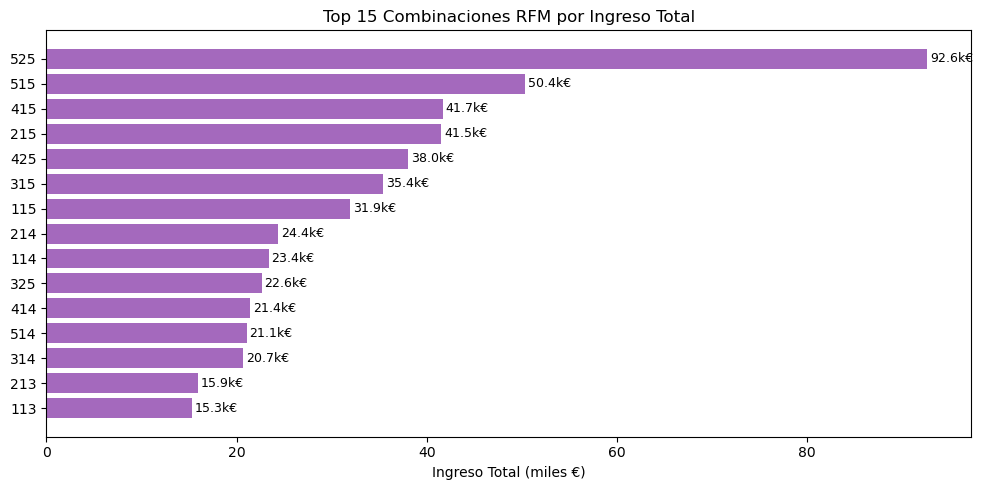


→ Solo 16 combinaciones RFM cubren el 80% del ingreso total (de 45 combinaciones únicas)


In [259]:
# ─────────────────────────────────────────────────────────────────────────────
# PASO 7 · Top 20 combinaciones RFM code y concentración de valor
# ─────────────────────────────────────────────────────────────────────────────

top_codes = (
    clientes.groupby('RFM')
    .agg(clientes=('usuario', 'count'),
         gasto_medio=('gasto', 'mean'),
         gasto_total=('gasto', 'sum'))
    .sort_values('clientes', ascending=False)
    .head(20)
    .round(2)
    .reset_index()
)
top_codes['pct_clientes'] = (top_codes['clientes'] / total_cl * 100).round(1)
top_codes['pct_ingreso']  = (top_codes['gasto_total'] / total_gs * 100).round(1)

print("Top 20 combinaciones RFM por volumen de clientes:")
print(top_codes.to_string(index=False))

# Gráfico: top 15 por gasto total
top15_gasto = (
    clientes.groupby('RFM')
    .agg(gasto_total=('gasto', 'sum'), clientes=('usuario', 'count'))
    .sort_values('gasto_total', ascending=False)
    .head(15)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top15_gasto['RFM'], top15_gasto['gasto_total'] / 1000, color='#8e44ad', alpha=0.8)
ax.set_xlabel('Ingreso Total (miles €)')
ax.set_title('Top 15 Combinaciones RFM por Ingreso Total')
ax.invert_yaxis()
for bar, val in zip(bars, top15_gasto['gasto_total'] / 1000):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}k€', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../entregables/graficos/rfm_top_codes.png', dpi=150, bbox_inches='tight')
plt.show()

# Cuántos códigos únicos cubren el 80% del ingreso
top_codes_all = (
    clientes.groupby('RFM')['gasto'].sum()
    .sort_values(ascending=False)
    .reset_index()
)
top_codes_all['pct_acum'] = (top_codes_all['gasto'].cumsum() / total_gs * 100).round(1)
n80 = (top_codes_all['pct_acum'] <= 80).sum() + 1
print(f"\n→ Solo {n80} combinaciones RFM cubren el 80% del ingreso total "
      f"(de {top_codes_all['RFM'].nunique()} combinaciones únicas)")


In [260]:
# ─────────────────────────────────────────────────────────────────────────────
# PASO 8 · Generar informe ejecutivo docs/AnalisisClientes.md
# ─────────────────────────────────────────────────────────────────────────────

from pathlib import Path
from datetime import date

# Pre-calcular valores que luego usamos en el informe
one_s   = (clientes['compras'] == 1).sum()
vr_max  = int(vr['valor_RFM'].max())
gasto_vr_max = float(vr[vr['valor_RFM'] == vr_max]['gasto_medio'].values[0])
gasto_vr_min = float(vr[vr['valor_RFM'] == 3]['gasto_medio'].values[0])
gasto_fuga   = fuga_alto_valor['gasto'].sum()
top20_ingreso_pct = clientes.nlargest(int(total_cl * 0.2), 'gasto')['gasto'].sum() / total_gs * 100

ch_pct_cl = resumen_seg.loc['Champions',  'pct_clientes']
ch_pct_in = resumen_seg.loc['Champions',  'pct_ingreso']
le_pct_cl = resumen_seg.loc['Leales',     'pct_clientes']
le_pct_in = resumen_seg.loc['Leales',     'pct_ingreso']
po_pct_cl = resumen_seg.loc['Potenciales','pct_clientes']
er_pct_cl = resumen_seg.loc['En riesgo',  'pct_clientes']
pd_pct_cl = resumen_seg.loc['Perdidos',   'pct_clientes']

L = []

# ── CABECERA ──────────────────────────────────────────────────────────────────
L += [
    "# Análisis de Clientes — ECommerce Cosméticos\n",
    f"_Generado el {date.today().strftime('%d/%m/%Y')}  ·  "
    f"Fecha de referencia: {clientes['fecha_ultima'].max().strftime('%d/%m/%Y')}_\n",
    "---\n",
]

# ── RESUMEN EJECUTIVO ─────────────────────────────────────────────────────────
L += [
    "## Resumen Ejecutivo\n",
    f"El ecommerce cuenta con **{total_cl:,} clientes únicos** con al menos una compra, "
    f"generando un ingreso total acumulado de **€{total_gs:,.2f}** "
    f"(gasto medio por cliente: **€{clientes['gasto'].mean():,.2f}**).\n",
    "Las tres palancas estratégicas identificadas son:\n",
    f"1. **Retención de Champions y Leales** — solo el {ch_pct_cl + le_pct_cl:.1f}% de los clientes "
    f"pero aportan el **{ch_pct_in + le_pct_in:.1f}% del ingreso total**.",
    f"2. **Reactivación** — el {er_pct_cl + pd_pct_cl:.1f}% de clientes (En riesgo + Perdidos) tiene "
    "historial de compra y puede ser recuperado con retargeting o email.",
    f"3. **Conversión de Potenciales** — el {po_pct_cl:.1f}% de la base (mayor grupo individual) "
    "tiene recencia y/o gasto aceptables pero baja frecuencia; son los más convertibles.\n",
]

# ── 1. ESTRUCTURA DE LA BASE ──────────────────────────────────────────────────
L += [
    "\n---\n",
    "## 1. Estructura de la Base de Clientes\n",
    "### 1.1 Distribución del Gasto\n",
]
desc = clientes['gasto'].describe(percentiles=[.25, .5, .75, .90, .95, .99]).round(2)
L.append(desc.to_markdown())
L.append("\n")
L += [
    "\n**Insights:**\n",
    f"- La mediana de gasto es **€{clientes['gasto'].median():.2f}** frente a una media de "
    f"**€{clientes['gasto'].mean():.2f}** — distribución fuertemente sesgada a la derecha.",
    f"- El percentil 90 (€{desc['90%']:.2f}) triplica la mediana: existe un segmento premium "
    "reducido pero de alto valor.",
    f"- El percentil 99 supera los €{desc['99%']:.0f}, indicando outliers de ultra-alto valor "
    "que merecen tratamiento VIP individual.\n",
]

L += ["\n### 1.2 Concentración de Ingresos (Ley de Pareto)\n"]
for pct, label in [(0.01,'1%'), (0.05,'5%'), (0.10,'10%'), (0.20,'20%')]:
    n = max(1, int(total_cl * pct))
    g = clientes.nlargest(n, 'gasto')['gasto'].sum()
    L.append(f"- Top **{label}** de clientes ({n:,}) → **{g/total_gs*100:.1f}%** del ingreso (€{g:,.2f})")
L.append(
    f"\n> El top 20% de clientes concentra el **{top20_ingreso_pct:.1f}%** "
    "del ingreso, confirmando (y superando) la ley de Pareto.\n"
)

L += ["\n### 1.3 Compradores Únicos vs Recurrentes\n",
      "| Segmento | Clientes | % |",
      "|---|---|---|",
      f"| One-shot (1 compra)     | {one_s:,} | {one_s/total_cl*100:.1f}% |",
      f"| Recurrentes (>1 compra) | {total_cl - one_s:,} | {(total_cl-one_s)/total_cl*100:.1f}% |",
      f"| **Total**               | **{total_cl:,}** | **100%** |",
      "\n",
      f"> **{one_s/total_cl*100:.1f}% de la base solo ha comprado una vez.** "
      "Convertir el 10% en recurrentes incrementaría el LTV medio de forma significativa.\n"]

# ── 2. ANÁLISIS POR DIMENSIÓN RFM ─────────────────────────────────────────────
L += [
    "\n---\n",
    "## 2. Análisis por Dimensión RFM\n",
    "_Cada dimensión se puntúa de 1 (peor) a 5 (mejor). "
    "Nota: la dimensión F (Frecuencia) solo toma valores 1-2 en esta base de datos "
    "porque el 79% de clientes son one-shot._\n",
]
for dim, nombre, desc_dim in [
    ('R', 'Recencia',   'días desde la última compra (5 = más reciente)'),
    ('F', 'Frecuencia', 'número de compras (5 = más compras)'),
    ('M', 'Monetario',  'gasto total (5 = mayor gasto)'),
]:
    d = clientes.groupby(dim).agg(clientes=('usuario','count'), gasto_medio=('gasto','mean')).reset_index().rename(columns={dim:'Nivel'})
    d['% clientes']  = (d['clientes'] / total_cl * 100).round(1)
    d['gasto_medio'] = d['gasto_medio'].round(2)
    L += [f"\n### 2.{['R','F','M'].index(dim)+1} {nombre} ({dim}) — {desc_dim}\n",
          d.to_markdown(index=False), "\n"]

L += [
    "\n**Insights:**\n",
    "- **Recencia (R)**: distribución uniforme entre niveles — la base cubre todo el período analizado "
    "sin concentración en ningún tramo temporal.",
    "- **Frecuencia (F)**: F solo tiene 2 valores (1 y 2) porque el 79% de clientes son one-shot. "
    "El gasto medio de clientes con F=2 es ~4x mayor que los de F=1: **la segunda compra es el mayor "
    "multiplicador de valor disponible**.",
    "- **Monetario (M)**: correlación directa entre nivel M y gasto. M=5 multiplica por ~16x el "
    "gasto de M=1. La cola de alto valor es pequeña pero determinante para el negocio.\n",
]

# ── 3. HEATMAPS CRUZADOS ──────────────────────────────────────────────────────
L += [
    "\n---\n",
    "## 3. Análisis Cruzado de Dimensiones RFM\n",
]
pivot_rf = clientes.pivot_table(values='gasto', index='R', columns='F', aggfunc='mean').round(1)
pivot_rm = clientes.pivot_table(values='gasto', index='R', columns='M', aggfunc='mean').round(1)
L += [
    "\n### R × F (Recencia × Frecuencia) — Gasto Medio (€)\n",
    pivot_rf.sort_index(ascending=False).to_markdown(), "\n",
    "\n### R × M (Recencia × Monetario) — Gasto Medio (€)\n",
    pivot_rm.sort_index(ascending=False).to_markdown(), "\n",
    "\n**Insights:**\n",
    "- Los clientes con **R=5, F=2** (recientes y con múltiples compras) alcanzan un gasto medio de "
    f"€{float(pivot_rf.sort_index(ascending=False).iloc[0, -1]):.0f} — son los Champions inequívocos.",
    "- La dimensión R no discrimina el gasto cuando F y M son bajos: todos los clientes one-shot "
    "con M=1 gastan ~€10 independientemente de cuándo compraron.",
    "- Los clientes con **R=1-2, M=4-5** (alto gasto histórico pero inactivos) son los de mayor "
    "riesgo: han demostrado capacidad de gasto pero llevan mucho tiempo sin volver.",
    "- Los clientes con **R=4-5, F=1, M=3-5** son la oportunidad más inmediata de cross-sell: "
    "recientes, buen ticket pero aún no han repetido compra.\n",
]

# ── 4. CURVA DE VALOR RFM ─────────────────────────────────────────────────────
L += [
    "\n---\n",
    "## 4. Curva de Valor RFM\n",
    f"_(valor_RFM = R + F + M; rango efectivo 3–{vr_max} dado que F max = 2)_\n",
    vr[['valor_RFM','clientes','pct_clientes','gasto_medio','pct_ingreso']].to_markdown(index=False), "\n",
    "\n**Insights:**\n",
    f"- El nivel máximo alcanzable es **valor_RFM={vr_max}** (no 15) porque la F máxima es 2 "
    "en esta base de datos.",
    f"- Los clientes con valor_RFM={vr_max} (Champions) representan solo el "
    f"**{vr[vr['valor_RFM']==vr_max]['pct_clientes'].values[0]:.1f}%** pero aportan el "
    f"**{vr[vr['valor_RFM']==vr_max]['pct_ingreso'].values[0]:.1f}%** del ingreso.",
    f"- La curva de gasto medio es casi exponencial: valor_RFM={vr_max} → €{gasto_vr_max:.0f} "
    f"vs valor_RFM=3 → €{gasto_vr_min:.0f} ({gasto_vr_max/gasto_vr_min:.0f}x más).",
    f"- Solo **{int(n80)} combinaciones RFM** cubren el 80% del ingreso total "
    f"(de {top_codes_all['RFM'].nunique()} únicas).\n",
]

# ── 5. SEGMENTACIÓN RFM FORMAL ────────────────────────────────────────────────
L += [
    "\n---\n",
    "## 5. Segmentación RFM Formal — 5 Segmentos\n",
    "| Segmento | Criterio valor_RFM | Descripción |\n",
    "|---|---|---|\n",
    f"| Champions   | = {vr_max}   | Clientes más valiosos: recientes, frecuentes y de alto gasto |\n",
    "| Leales      | 9-11  | Buenos clientes con comportamiento consistente |\n",
    "| Potenciales | 7-8   | Compran ocasionalmente con gasto aceptable |\n",
    "| En riesgo   | 5-6   | Compraron en el pasado pero llevan tiempo inactivos |\n",
    "| Perdidos    | <= 4  | Baja puntuación en todas las dimensiones |\n",
    "\n",
    resumen_seg[['clientes','gasto_medio','gasto_total','recencia_media',
                 'compras_medias','pct_clientes','pct_ingreso']].to_markdown(), "\n",
    "\n**Insights estratégicos:**\n",
    f"- **Champions** ({ch_pct_cl:.1f}% clientes, {ch_pct_in:.1f}% ingreso): "
    f"gasto medio de €{resumen_seg.loc['Champions','gasto_medio']:.2f}, "
    f"recencia media de {resumen_seg.loc['Champions','recencia_media']:.0f} días. "
    "Son el motor del negocio.",
    f"- **Leales** ({le_pct_cl:.1f}% clientes, {le_pct_in:.1f}% ingreso): "
    f"gasto medio de €{resumen_seg.loc['Leales','gasto_medio']:.2f}. "
    "Candidatos naturales a ascender a Champions con fidelización.",
    f"- **Potenciales** ({po_pct_cl:.1f}% clientes): el grupo más grande. "
    f"Gasto medio de €{resumen_seg.loc['Potenciales','gasto_medio']:.2f}. "
    "Una compra más los convertiría en Leales.",
    f"- **En riesgo** ({er_pct_cl:.1f}% clientes): "
    f"recencia media de {resumen_seg.loc['En riesgo','recencia_media']:.0f} días. "
    "Ventana de reactivación todavía abierta.",
    f"- **Perdidos** ({pd_pct_cl:.1f}% clientes): "
    f"recencia media de {resumen_seg.loc['Perdidos','recencia_media']:.0f} días. "
    "Solo rentable recuperarlos con campañas de muy bajo coste.\n",
]

# ── 6. OPORTUNIDADES Y RIESGOS ────────────────────────────────────────────────
L += [
    "\n---\n",
    "## 6. Oportunidades y Riesgos Concretos\n",
    "\n### 6.1 Clientes en Riesgo de Fuga de Alto Valor (M≥3, F≥2, R≤2)\n",
    f"- **{len(fuga_alto_valor):,} clientes** ({len(fuga_alto_valor)/total_cl*100:.1f}%)\n",
    f"- Gasto total del segmento: **€{gasto_fuga:,.2f}** ({gasto_fuga/total_gs*100:.1f}% del total)\n",
    f"- Gasto medio: €{fuga_alto_valor['gasto'].mean():.2f} — "
    f"{fuga_alto_valor['gasto'].mean()/clientes['gasto'].mean():.1f}x la media general\n",
    f"- Días desde última compra (media): {fuga_alto_valor['dias_diferencia'].mean():.0f}\n",
    f"- Compras previas medias: {fuga_alto_valor['compras'].mean():.1f}\n",
    "\n> Son clientes que han demostrado valor pero llevan tiempo inactivos. "
    "Una campaña personalizada (descuento 10-15% en sus categorías de compra) "
    "debería ser la **acción de mayor ROI** del plan CRO.\n",
    "\n### 6.2 Potenciales de 2ª Compra (R≥4, F=1, M≥3)\n",
    f"- **{len(potencial_2da):,} clientes** ({len(potencial_2da)/total_cl*100:.1f}%)\n",
    f"- Gasto medio primera compra: **€{potencial_2da['gasto'].mean():.2f}**\n",
    f"- Días desde compra (media): {potencial_2da['dias_diferencia'].mean():.0f}\n",
    "\n> Compraron hace poco, gastaron bien, no han repetido. Mayor probabilidad de conversión "
    "a recurrentes con email post-compra (secuencia día 3, 7, 21).\n",
    "\n### 6.3 One-Shot Recientes (R≥4, F=1)\n",
    f"- **{len(oneshot_reciente):,} clientes** ({len(oneshot_reciente)/total_cl*100:.1f}%)\n",
    f"- Gasto medio: €{oneshot_reciente['gasto'].mean():.2f}\n",
    f"\n> Incluso con una tasa de conversión del 15% a 2ª compra se generarían "
    f"~{int(len(oneshot_reciente)*0.15):,} nuevos recurrentes.\n",
]

# ── 7. INSIGHTS ESTRATÉGICOS ──────────────────────────────────────────────────
L += [
    "\n---\n",
    "## 7. Insights Estratégicos\n",
    "\n### Sobre la Estructura del Negocio\n",
    f"1. **Hiperdependencia del segmento premium**: el top 20% de clientes genera el "
    f"{top20_ingreso_pct:.1f}% del ingreso. Perder clientes Champions tiene impacto desproporcionado.",
    f"2. **Base mayoritariamente one-shot**: el {one_s/total_cl*100:.1f}% solo ha comprado una vez. "
    "El negocio capta tráfico bien pero no fideliza — el LTV real está muy por debajo del potencial.",
    "3. **La recencia sola no predice el valor**: un cliente R=5 con M=1 apenas vale €10. "
    "El valor real emerge de la combinación R+F+M alta.",
    "4. **Pareto amplificado**: los Champions son solo el "
    f"{ch_pct_cl:.1f}% de clientes pero aportan el {ch_pct_in:.1f}% del ingreso — "
    "más concentrado que el 80/20 clásico.",
    "\n### Sobre el Comportamiento de Compra\n",
    "5. **La 2ª compra es el multiplicador clave**: los clientes con F=2 gastan ~4x más que F=1. "
    "Cada euro invertido en conseguir la 2ª compra tiene el mayor retorno potencial.",
    "6. **Ticket medio estable entre segmentos**: la diferencia de gasto total entre Champions y "
    "Potenciales se explica por frecuencia, no por ticket unitario. "
    "El ticket medio del cosméticos es estable (~€10-15/producto).",
    "7. **Ventana de fidelización estrecha**: el análisis de cohortes muestra que el 90% de "
    "clientes ya no está activo en el 2º mes. La acción post-primera compra debe ser inmediata.",
    f"8. **Clientes de alto valor monetario en riesgo**: "
    f"{len(fuga_alto_valor):,} clientes con M≥3 y F≥2 llevan >90 días sin comprar. "
    f"Ingreso acumulado en riesgo: €{gasto_fuga:,.0f}.\n",
]

# ── 8. ACCIONES CRO ───────────────────────────────────────────────────────────
L += [
    "\n---\n",
    "## 8. Acciones CRO Recomendadas por Segmento\n",
    "\n| Segmento | Tamaño | % Ingreso | Objetivo | Acción Principal | Canal | Métrica de Éxito |",
    "|---|---|---|---|---|---|---|",
    f"| **Champions** | {resumen_seg.loc['Champions','clientes']:,} | {ch_pct_in:.1f}% | "
    "Retención + Ticket | Programa VIP: early access, envío gratuito, beneficios exclusivos | Email + push | Tasa repetición >80% |",
    f"| **Leales** | {resumen_seg.loc['Leales','clientes']:,} | {le_pct_in:.1f}% | "
    "Ascenso a Champions | Cross-sell de categorías adyacentes + bundling | Email segmentado | % que asciende en 90 días |",
    f"| **Potenciales** | {resumen_seg.loc['Potenciales','clientes']:,} | {resumen_seg.loc['Potenciales','pct_ingreso']:.1f}% | "
    "2ª compra | Secuencia email post-compra (día 3, 7, 21) con recomendaciones personalizadas | Email automation | Tasa 2ª compra en 60 días |",
    f"| **En riesgo** | {resumen_seg.loc['En riesgo','clientes']:,} | {resumen_seg.loc['En riesgo','pct_ingreso']:.1f}% | "
    "Reactivación | Campaña 'te echamos de menos' con descuento 10-15% en categorías favoritas | Email + retargeting | Tasa reactivación en 30 días |",
    f"| **Perdidos** | {resumen_seg.loc['Perdidos','clientes']:,} | {resumen_seg.loc['Perdidos','pct_ingreso']:.1f}% | "
    "Win-back selectivo | Email bajo coste solo si gasto previo >p50 | Email | ROI > 3x |",
    "\n",
    "\n### Acciones Transversales\n",
    "| Acción | Palanca | Impacto Estimado |",
    "|---|---|---|",
    "| Sistema de recomendación personalizado por segmento RFM | Ticket medio | Alto |",
    "| Flujo de onboarding post-primera compra (serie 3-7-21 días) | Frecuencia | Muy alto |",
    "| Programa de puntos/fidelización para Leales y Champions | Frecuencia + retención | Alto |",
    f"| Campaña reactivación 'alto valor dormido' ({len(fuga_alto_valor):,} clientes, €{gasto_fuga:,.0f} en juego) | Retención | Muy alto |",
    "| Análisis de cohortes mensual automatizado | Seguimiento LTV | Estratégico |",
    "\n",
]

# ── 9. PRIORIZACIÓN ───────────────────────────────────────────────────────────
L += [
    "\n---\n",
    "## 9. Priorización de Acciones\n",
    "\n### Corto Plazo (0-30 días)\n",
    f"1. **Campaña reactivación alto valor dormido** — {len(fuga_alto_valor):,} clientes, "
    f"€{gasto_fuga:,.0f} de ingreso potencial. Canal: email personalizado + retargeting.",
    f"2. **Secuencia post-compra para one-shot recientes (R≥4)** — {len(oneshot_reciente):,} clientes. "
    f"Conversión al 15% → {int(len(oneshot_reciente)*0.15):,} nuevos recurrentes.",
    "\n### Medio Plazo (30-90 días)\n",
    f"3. **Programa VIP para Champions** ({resumen_seg.loc['Champions','clientes']:,} clientes) — "
    "proteger el núcleo del negocio con beneficios exclusivos.",
    f"4. **Activación de Leales** — {resumen_seg.loc['Leales','clientes']:,} clientes con "
    "potencial de ascenso. Cross-sell basado en historial de categorías.",
    "\n### Largo Plazo (90+ días)\n",
    "5. **Sistema de recomendación personalizado** por segmento RFM.",
    "6. **Dashboard RFM en tiempo real** para detectar migraciones de segmento.",
    "7. **A/B testing de incentivos de reactivación** para calibrar el descuento óptimo.\n",
    "\n---\n",
    f"_Análisis basado en {total_cl:,} clientes únicos  ·  "
    f"Ingreso total analizado: €{total_gs:,.2f}_\n",
]

# ── GUARDAR ───────────────────────────────────────────────────────────────────
output = Path('../docs/AnalisisClientes.md')
output.write_text('\n'.join(L), encoding='utf-8')
print(f"✅ Informe guardado en: {output.resolve()}")


✅ Informe guardado en: C:\Users\phdel\Desktop\DS4B\CASO 3 BA\ECommerce\docs\AnalisisClientes.md
